## 📌 Introduction

This notebook focuses on the **data exploration phase** . The main objectives of this exploration are to:

- Understand the overall structure and size of the dataset  
- Identify attribute types and key features  
- Assess data quality issues such as missing, inconsistent, or extreme values  
- Generate descriptive statistics for numerical and categorical attributes  
- Visualize data distributions and basic relationships between variables  
- Document initial observations to inform later preprocessing and data mining tasks  

At this stage, no data cleaning, transformation, or mining techniques are applied. The goal is solely to **understand the data** and prepare for subsequent analysis.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path('..').resolve()
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J).csv'
CLEANED_DATA_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J)_cleaned.csv'
CHANGE_LOG_PATH = PROJECT_ROOT / 'results' / 'data_cleaning_change_log.txt'
CLEANED_FEATURES_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'Driving_Data_Selected_Features_Risky_Label.csv'
TRANSFORMED_DATA_PATH = PROJECT_ROOT / 'data' / 'transformed' / 'Driving_Data_With_Risky_Label.csv'


sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
np.random.seed(42)
df = pd.read_csv("../data/raw/Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J).csv")


display(df['Fuel_Pressure'])

sampled_df = df.groupby("Class").apply(lambda x: x.sample(n=5, random_state=1)).reset_index(drop=True)

df_sorted = df.sort_values(by="Time(s)", ascending=True)
df_sorted_id = df.sort_values(by="Class", ascending=True)


class_counts = df["Engine_in_fuel_cut_off"].value_counts()
print(class_counts)



0        0
1        0
2        0
3        0
4        0
        ..
94375    0
94376    0
94377    0
94378    0
94379    0
Name: Fuel_Pressure, Length: 94380, dtype: int64

Engine_in_fuel_cut_off
0    88033
1     6347
Name: count, dtype: int64


C:\Users\idris\AppData\Local\Temp\ipykernel_23556\1330022844.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby("Class").apply(lambda x: x.sample(n=5, random_state=1)).reset_index(drop=True)




Each driver (A–J) has many rows because the data are recorded continuously over time. Each row represents sensor readings at a specific time instant, not a unique driver. Therefore, a single driver generates thousands of samples corresponding to different driving situations.



## 🛢️ Fuel & Air Management

- **Fuel_consumption:** Engine fuel usage, used to assess efficiency and emissions.

        Type : continuous and vals : [0.0, 10931.2]
- **Fuel_Pressure:** Fuel pressure supplied to injectors, affecting combustion quality.

        all values are 0 , lapobel 🗑️
- **Intake_air_pressure:** Air pressure entering the engine, indicating engine load.

        Type : discrete and vals :  [0, 178]

- **Calculated_LOAD_value:** Estimated engine load based on airflow and RPM (how hard the engine is working at a given moment).

        It is calculated by the ECU (Engine Control Unit) using inputs such as:
            . Airflow into the engine (Intake air pressure)
            . Engine speed (RPM)
            . Throttle position
            . Fuel injection or fuel pressure

        Type : continuous and vals : [0.0, 98.4]

## 🦶 Driver Input & Throttle (controls how much air enters the engine)

- **Accelerator_Pedal_value:** Raw accelerator pedal position showing driver demand.

        Type : continous and vals :  [0.0, 99.2]

- **Filtered_Accelerator_Pedal_value:** Smoothed accelerator signal for stable control(Accelerator_Pedal_value with filtering ).

        all values are 0 so 🗑️

- **Throttle_position_signal:** Throttle opening signal controlling air intake.

        Type : continuous and vals : [0.0, 100.0] 

- **Absolute_throttle_position:** Actual throttle plate position(physical angle of the throttle plate).

        Type : continuous and vals : [12.5, 84.3]


## 🔥 Fuel Trim & Combustion

    Term_Fuel : air–fuel mixture to be just right .
        - Air–fuel ratio (AFR) = ratio of air to fuel in the engine.
        - If it’s off, the ECU adjusts the fuel using fuel trims.

- **Short_Term_Fuel_Trim_Bank1:** Short-term fuel correction for air–fuel ratio control.

        Type : continuous and vals : [-15.6, 23.4]

- **Long_Term_Fuel_Trim_Bank1:** Long-term fuel correction compensating persistent deviations.

        Type : continuous and vals : [-1.6, 10.2]


- **Current_spark_timing:** Ignition timing affecting power and efficiency.

        Type : continuous and vals : [-35.6, 50.3]

## 🧠 Engine State

- **Engine_speed:** Engine speed in RPM(Revolutions Per Minute).

        Type : discrete and vals : [0, 6253]

- **Engine_Idel_Target_Speed:** Target RPM during idle.

        Type : discrete and vals : [0, 1550]

- **Engine_soacking_time:** Time engine remains heat-soaked after shutdown.

        Type : discrete and vals : [0, 255] (minutes)

- **Engine_coolant_temperature:** Engine coolant temperature indicating thermal state.

        temperature of the engine coolant (the liquid that circulates inside the engine to remove heat) , tell how cold or hot the engin is .

        Type : discrete and vals : [-40, 96] (°C)

- **Engine_coolant_temperature.1:** Redundant coolant temperature measurement(not duplicate , it has different values).
        Type : discrete and vals : [-40, 105] (°C)

## ⚙️ Torque & Power

- **Engine_torque:** Torque (Force) produced by the engine(theoretical torque engine).

        Type : continuous and vals :[0.0, 83.6] (Newton-meters (N·m))

- **Engine_torque_after_correction:** Engine torque after ECU corrections(Engine Control Unit)like for slipping wheels it will reduce the force.

        Same type and values .

- **Minimum_indicated_engine_torque:** Minimum allowed engine torque.

        Type : continuous and vals : [0.0, 8.2]

- **Maximum_indicated_engine_torque:** Maximum achievable engine torque.

        Type : Continuous and vals : [0.0, 91.4]

- **Torque_of_friction:** Torque lost to internal engine friction.

        Type : continuous and vals : [0.0, 28.1]

- **Flywheel_torque:** Torque at the engine flywheel(actual torque engine).

        Type : continuous and vals :  [-47.5, 158.4]

- **Flywheel_torque_(after_torque_interventions):** Flywheel torque after ECU interventions.

        Same values and type

- **Torque_scaling_factor(standardization):** Scaling factor used to normalize torque values.

        all values 230 (int) probably 🗑️.


- **Standard_Torque_Ratio:** Ratio of current torque to reference torque(how hard the engine is working compared to its normal or maximum capability).

        Type : binary and vals : [0, 1] (it is a ration but we only get two value 0  or one )so in this case the info we get is : is the engine deliver the max torque or not . 
        

## 🛑 Fuel Cut-off & Protection

        Fuel cut-off : stop injecting fuel when it’s not needed

- **Inhibition_of_engine_fuel_cut_off:** Indicates fuel cut-off inhibition status(disabled or allowed).

        all values are 0  , so probably 🗑️.

- **Engine_in_fuel_cut_off:** Indicates active fuel cut-off during deceleration(wether currently not injecting fuel).

        Type : binary vals 

## 🔁 Transmission & Converter

- **Current_Gear:** Currently engaged gear.

        Type : discrete and vals : [0, 14]

- **Gear_Selection:** Selected gear by driver or system.

        Type : discrete and vals : [0, 15]

- **Torque_converter_speed:** Speed of the torque converter.

        Type : continuous and vals : [0.0, 6234.0](RPM)

- **Torque_converter_turbine_speed_Unfiltered:** Raw turbine speed measurement.

        Type : continuous and vals : [0.0,6236.5](RPM)

- **Converter_clutch:** Torque converter lock-up clutch state(disengaged, engaged or sliped (partially engaged)).

        Type : discrete and vals :  [0, 2]

- **Clutch_operation_acknowledge:** Acknowledgement of clutch operation (yer or no ).

        Type : binary  and vals :  [0, 2]

## 🚗 Vehicle Dynamics

- **Vehicle_speed:** Vehicle speed.

        Type : discrete and vals : [0, 129]

- **Wheel_velocity_front_left-hand:** Front-left wheel speed.

        Type : continuous and vals : [0.0, 135.1]

- **Wheel_velocity_front_right-hand:** Front-right wheel speed.

        Type : continuous and vals :[0.0, 133.9]


- **Wheel_velocity_rear_left-hand:** Rear-left wheel speed.

        Type : continuous and vals :[0.0, 134.1]

- **Wheel_velocity_rear_right-hand:** Rear-right wheel speed.

        Type : continuous and vals :[0.0, 133.2]

- **Acceleration_speed_Longitudinal:** Longitudinal acceleration or deceleration.

        Type : continuous and vals : [-10.2, 8.1]

- **Acceleration_speed_Lateral:** Lateral acceleration during cornering.

        Type : continuous and vlas : [-10.2, 8.1]

## 🧭 Steering & Road

- **Steering_wheel_angle:** Steering wheel angle.

        Type : continuous and vals [-516.8, 530.3]

- **Steering_wheel_speed:** Rate of steering input.

        Type : discrete and vals :[0, 632]

- **Calculated_road_gradient:** Estimated road slope.

        Type : continuous and vals : [-16.0, 15.5]

## 🛑 Braking

- **Indication_of_brake_switch_ON/OFF:** Brake pedal status.

        Type : binary and vals [0, 2] (2 can indicate on invalid/unknown)

- **Master_cylinder_pressure:** Brake hydraulic pressure.

        Type : continuous and vals : [0.0, 395.9] (unit bar)

## ❄️ Auxiliary

- **Glow_plug_control_request:** Glow plug activation request.

        all values are 0

- **Activation_of_Air_compressor:** Air conditioning compressor status.

        Type : binary and values 0 or 1

## 🧠 ECU / TCU Requests

- **Requested_spark_retard_angle_from_TCU:** Spark retard requested by transmission.

        Type : discrete and vals :  [-15, 15]

- **TCU_requests_engine_torque_limit_(ETL):** Engine torque limit request from TCU.

        Type : discrete and vals : [0, 508]

- **TCU_requested_engine_RPM_increase:** Request to increase engine RPM.

        Type : continuous  and vals : [0.0, 21.1]

- **Target_engine_speed_used_in_lock-up_module:** Target RPM for torque converter lock-up.

        type :  countinuous and vals  [500, 3040]


## 🕒 Metadata

- **Time(s):** Time stamp in seconds.

        Type : discrete and vals [1, 2948]

- **Class:** Driver IDs (10).

        Vals : [A, J] where for each driver we have : 
                
                D    13244
                B    12864
                F    11012
                H     9880
                J     8904
                E     8436
                I     7808
                C     7500
                G     7492
                A     7240
                        

- **PathOrder:** Trip or path sequence identifier (first path or second path ).

        vals : [1, 2]




In [260]:
print('Shape:', df.shape)
print('\nInfo:')
df.info()

Shape: (94380, 54)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94380 entries, 0 to 94379
Data columns (total 54 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Fuel_consumption                              94380 non-null  float64
 1   Accelerator_Pedal_value                       94380 non-null  float64
 2   Throttle_position_signal                      94380 non-null  float64
 3   Short_Term_Fuel_Trim_Bank1                    94380 non-null  float64
 4   Intake_air_pressure                           94380 non-null  int64  
 5   Filtered_Accelerator_Pedal_value              94380 non-null  int64  
 6   Absolute_throttle_position                    94380 non-null  float64
 7   Engine_soacking_time                          94380 non-null  int64  
 8   Inhibition_of_engine_fuel_cut_off             94380 non-null  int64  
 9   Engine_in_fuel_cut_off             

In [261]:
df_eda = df.copy()
print('\nNumeric summary:')
display(df_eda.describe())

print("Missing values per column:")
display(df_eda.isnull().sum())


Numeric summary:


,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,Fuel_Pressure,Long_Term_Fuel_Trim_Bank1,Engine_speed,Engine_torque_after_correction,Torque_of_friction,Flywheel_torque_(after_torque_interventions),Current_spark_timing,Engine_coolant_temperature,Engine_Idel_Target_Speed,Engine_torque,Calculated_LOAD_value,Minimum_indicated_engine_torque,Maximum_indicated_engine_torque,Flywheel_torque,Torque_scaling_factor(standardization),...,TCU_requested_engine_RPM_increase,Target_engine_speed_used_in_lock-up_module,Glow_plug_control_request,Activation_of_Air_compressor,Torque_converter_speed,Current_Gear,Engine_coolant_temperature.1,Wheel_velocity_front_left-hand,Wheel_velocity_rear_right-hand,Wheel_velocity_front_right-hand,Wheel_velocity_rear_left-hand,Torque_converter_turbine_speed_-_Unfiltered,Clutch_operation_acknowledge,Converter_clutch,Gear_Selection,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),PathOrder
count,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.0,94380.000000,94380.000000,94380.0,94380.000000,94380.0,94380.000000,94380.000000,94380.000000,94380.00000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.00000,94380.000000,94380.000000,94380.000000,94380.0,...,94380.000000,94380.000000,94380.0,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000
mean,757.000246,3.718682,13.208186,0.122782,36.853433,0.0,19.362277,26.795327,0.0,0.067249,0.0,2.843127,1422.838885,23.813976,13.69958,22.820449,10.506642,84.346800,895.345624,23.757734,42.30515,1.946885,67.572107,22.738693,230.0,...,0.136569,3039.919263,0.0,0.890581,1259.509722,3.250085,84.615628,30.113410,29.209106,29.362165,29.901012,1259.950517,0.627792,0.612810,4.877474,28.518881,-0.076198,1.356294,5.686715,0.300419,-0.007616,6.362407,0.773593,1110.031765,1.513583
std,761.376214,8.505756,16.262249,3.166412,27.957584,0.0,12.079046,73.072712,0.0,0.250455,0.0,1.362755,613.428059,14.633545,2.27353,36.523296,13.401414,6.140172,178.836264,14.733961,18.38917,0.694589,9.576038,36.745301,0.0,...,1.266017,14.320222,0.0,0.312166,766.150141,2.149919,13.639351,26.480625,26.107705,26.223972,26.315974,766.265828,0.483396,0.847272,0.936442,25.309664,0.593006,0.479017,9.904240,2.210411,0.417956,26.467043,60.815388,683.042550,0.499818
min,0.000000,0.000000,0.000000,-15.600000,0.000000,0.0,12.500000,0.000000,0.0,0.000000,0.0,-1.600000,0.000000,0.000000,0.00000,-47.500000,-35.600000,-40.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-47.500000,230.0,...,0.000000,500.000000,0.0,0.000000,0.000000,0.000000,-40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-10.200000,0.000000,0.000000,-16.000000,-10.200000,0.000000,-516.800000,1.000000,1.000000
25%,320.000000,0.000000,6.600000,-1.600000,4.000000,0.0,14.500000,1.000000,0.0,0.000000,0.0,2.300000,823.000000,14.800000,12.50000,0.300000,-1.500000,84.000000,800.000000,14.800000,27.10000,2.000000,57.000000,0.300000,230.0,...,0.000000,3040.000000,0.0,1.000000,668.800000,1.000000,83.000000,4.500000,3.900000,4.000000,4.400000,669.300000,0.000000,0.000000,5.000000,4.000000,-0.300000,1.000000,1.000000,0.000000,-0.100000,0.000000,-2.600000,537.000000,1.000000
50%,422.400000,0.000000,7.500000,0.000000,38.000000,0.0,15.300000,3.000000,0.0,0.000000,0.0,3.100000,1473.000000,20.300000,13.70000,12.700000,6.800000,85.000000,900.000000,20.300000,41.60000,2.000000,69.500000,12.900000,230.0,...,0.0

Missing values per column:


Fuel_consumption                                0
Accelerator_Pedal_value                         0
Throttle_position_signal                        0
Short_Term_Fuel_Trim_Bank1                      0
Intake_air_pressure                             0
Filtered_Accelerator_Pedal_value                0
Absolute_throttle_position                      0
Engine_soacking_time                            0
Inhibition_of_engine_fuel_cut_off               0
Engine_in_fuel_cut_off                          0
Fuel_Pressure                                   0
Long_Term_Fuel_Trim_Bank1                       0
Engine_speed                                    0
Engine_torque_after_correction                  0
Torque_of_friction                              0
Flywheel_torque_(after_torque_interventions)    0
Current_spark_timing                            0
Engine_coolant_temperature                      0
Engine_Idel_Target_Speed                        0
Engine_torque                                   0


## Possible Otliers

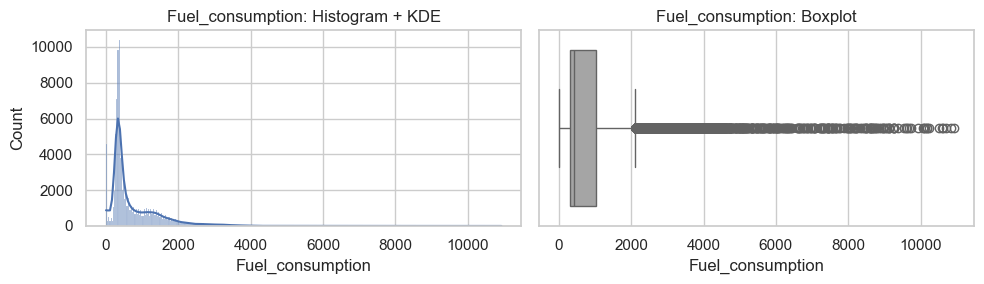

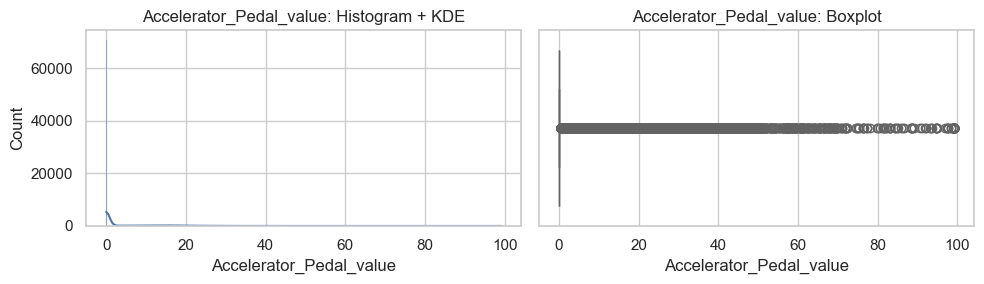

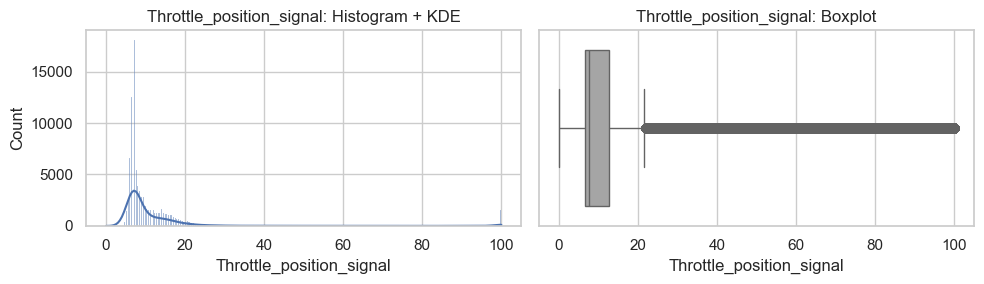

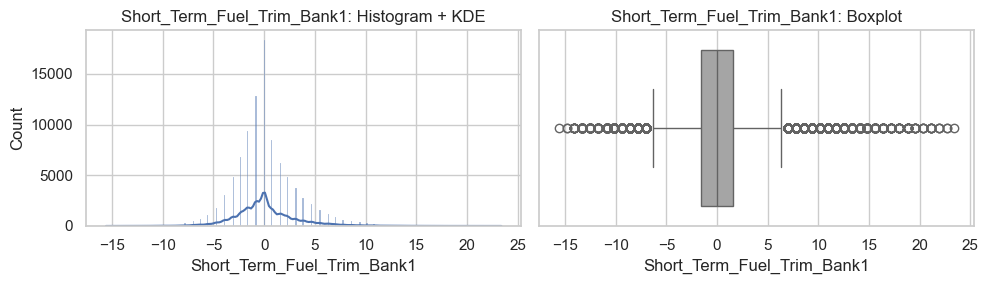

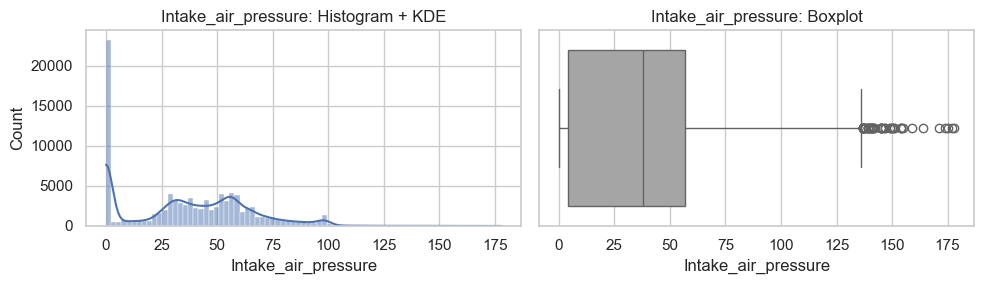

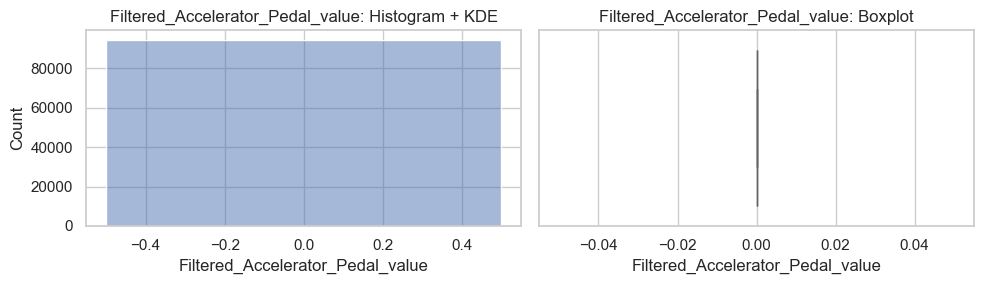

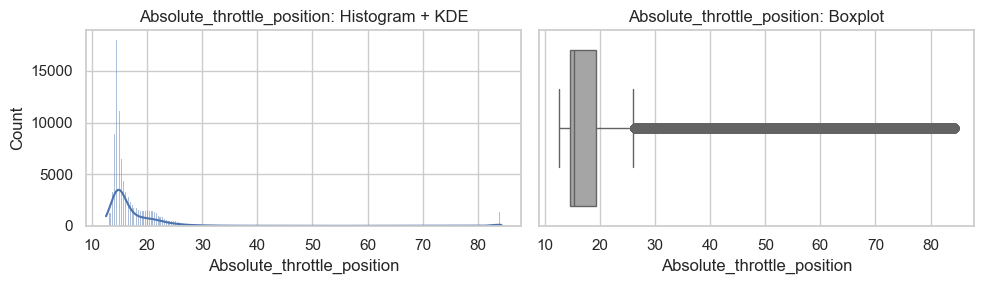

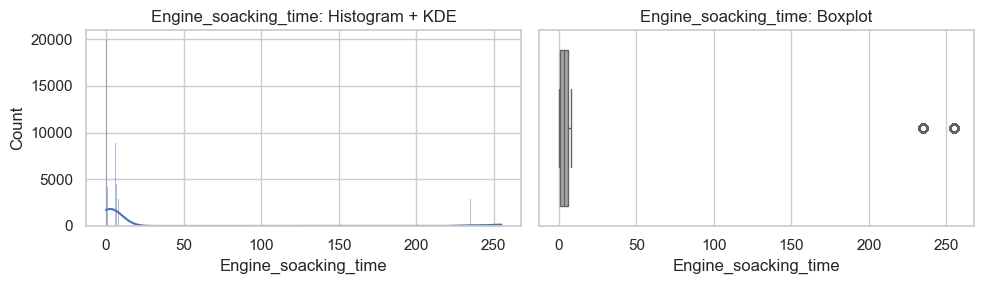

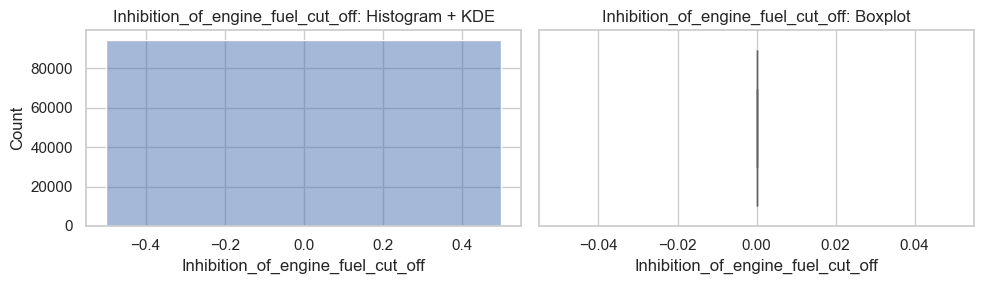

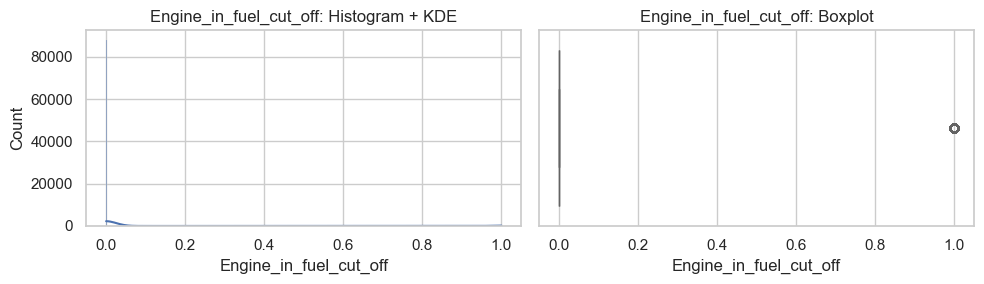

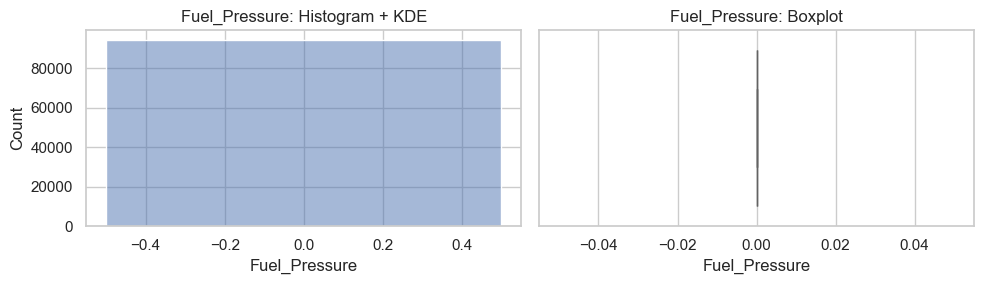

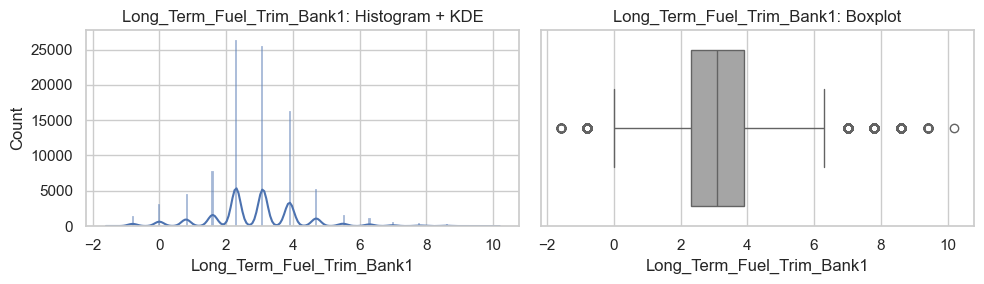

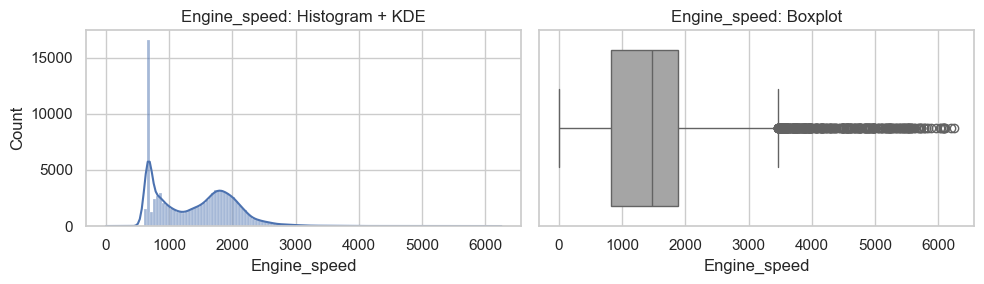

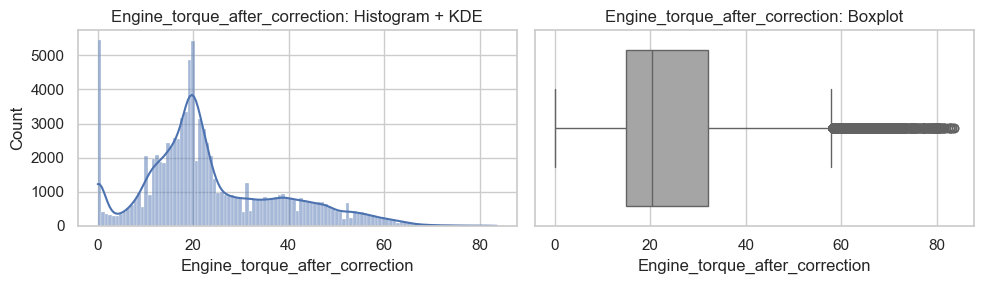

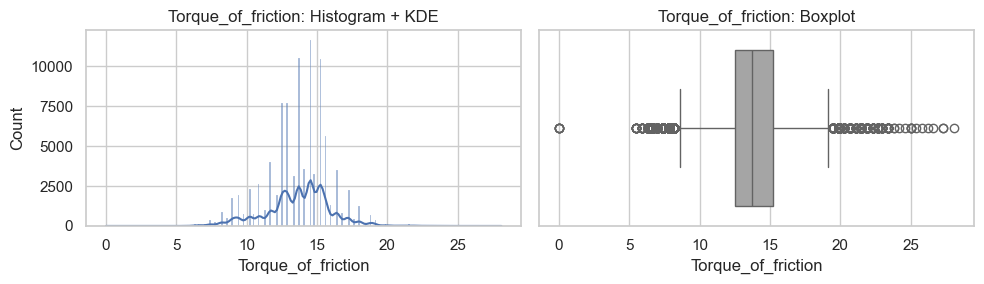

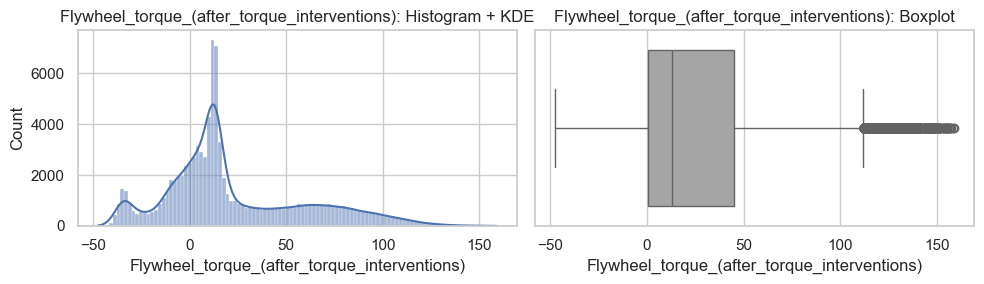

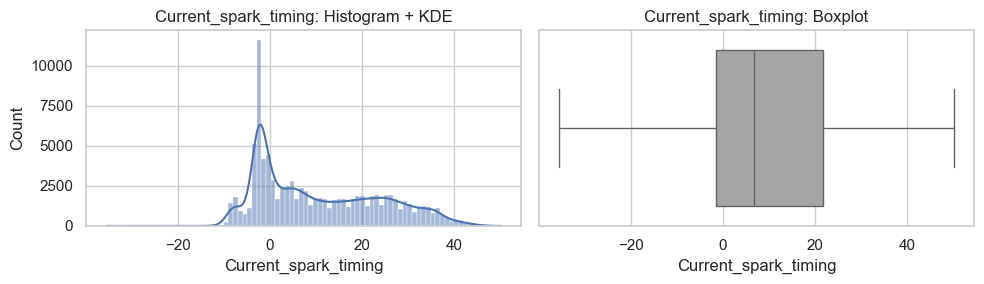

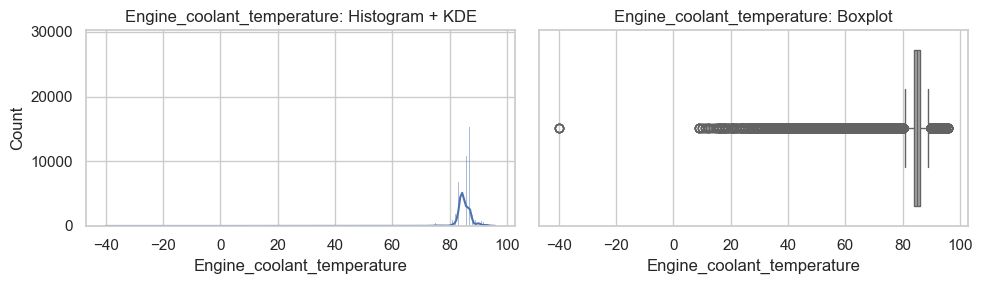

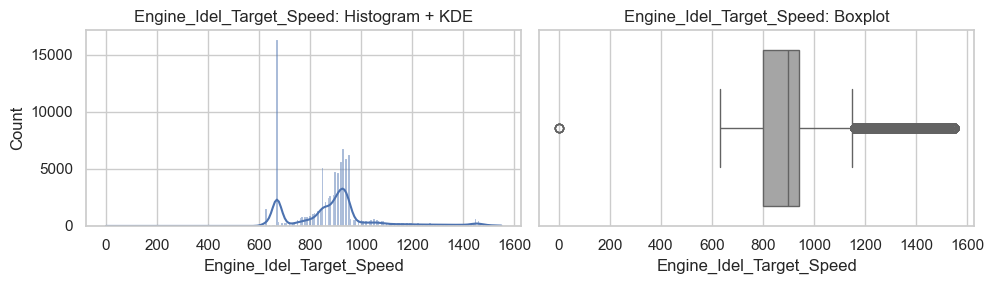

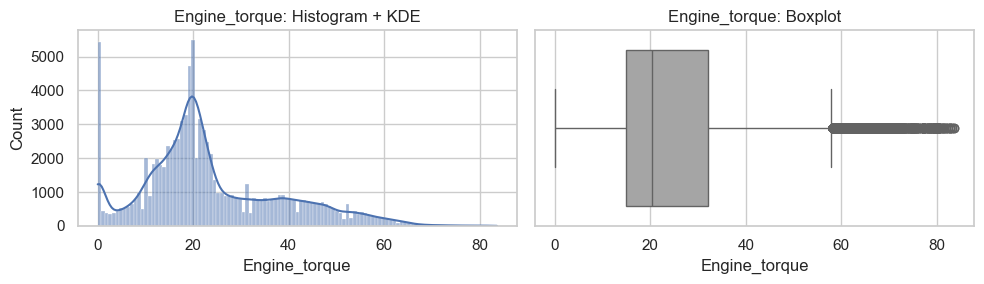

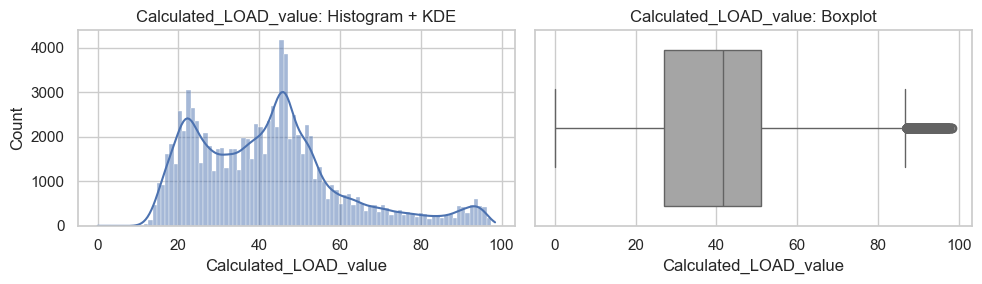

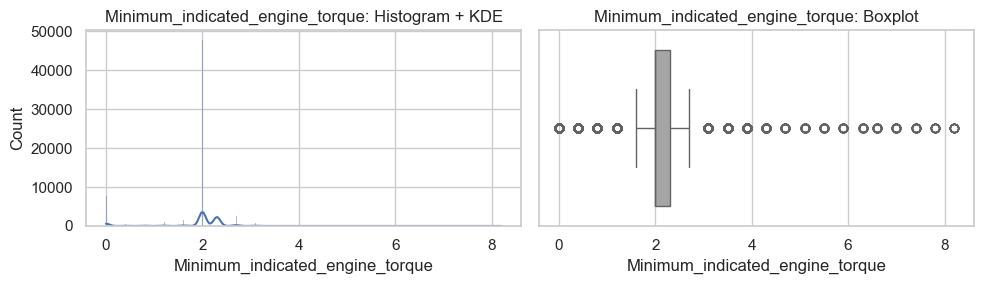

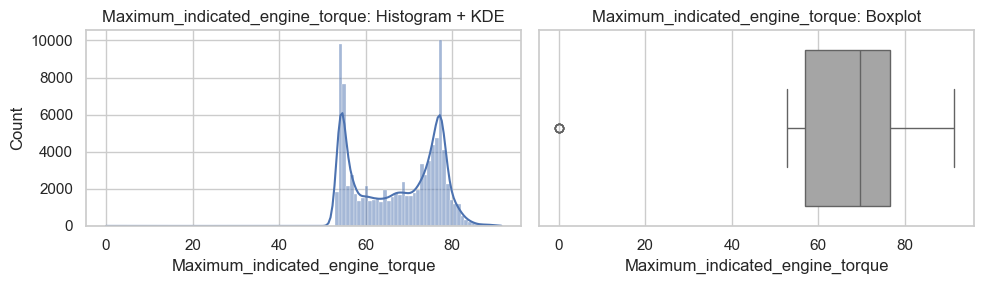

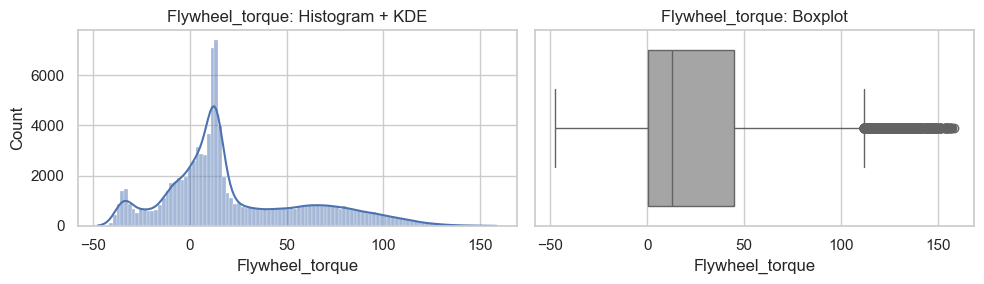

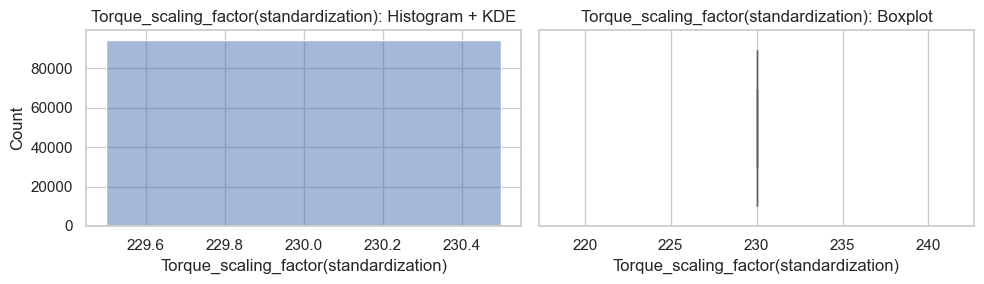

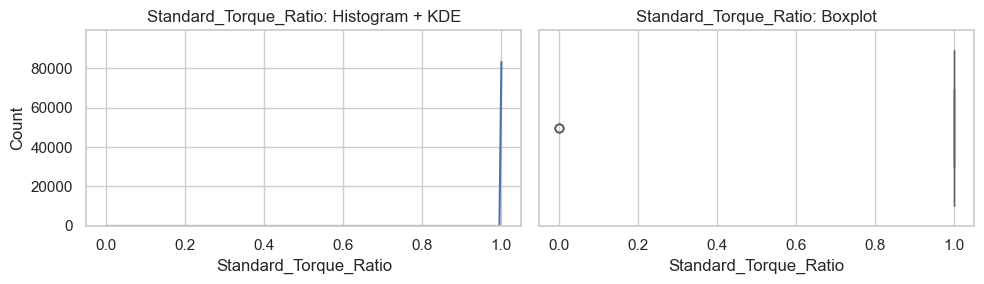

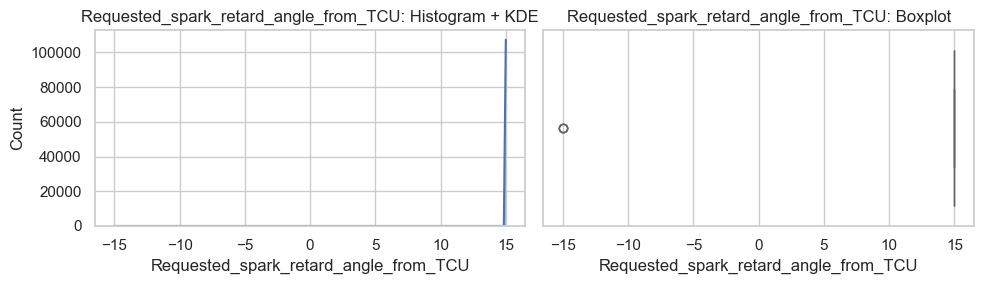

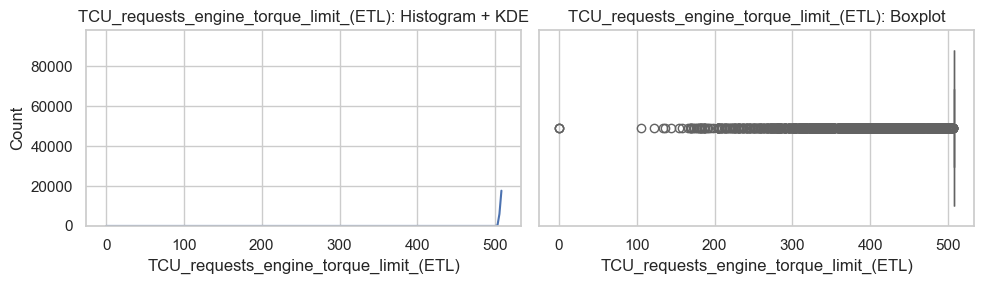

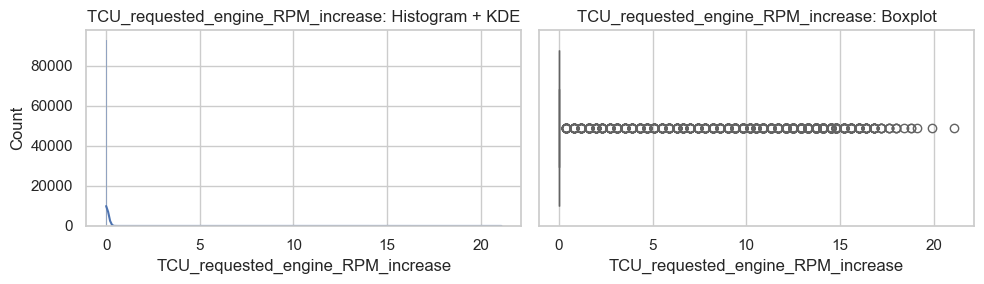

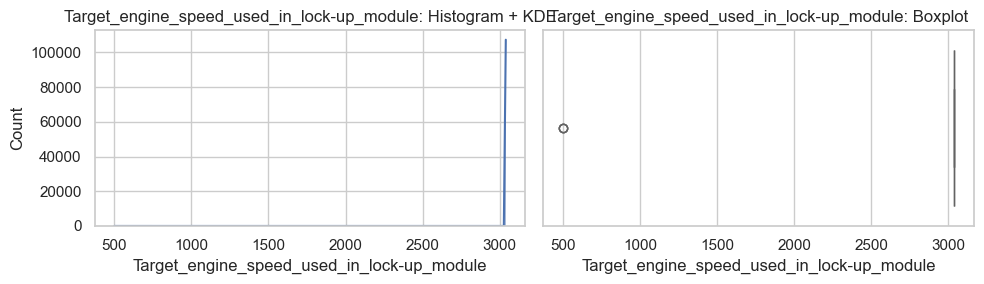

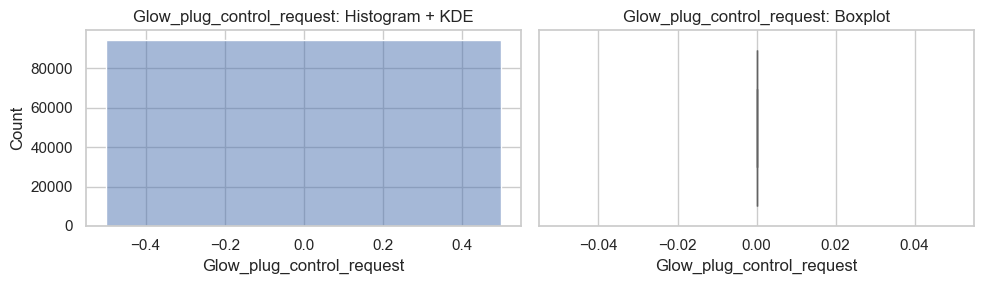

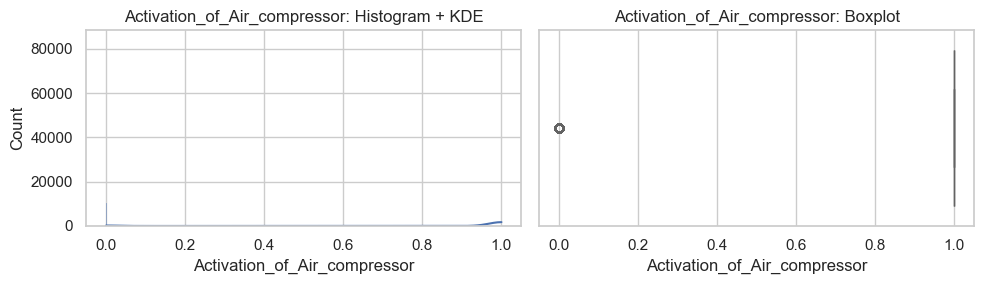

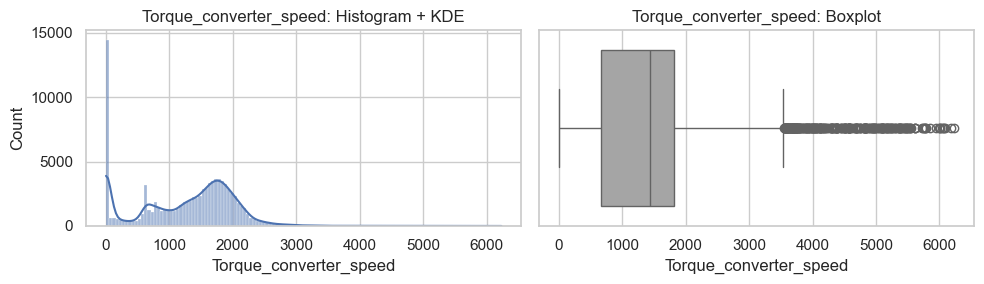

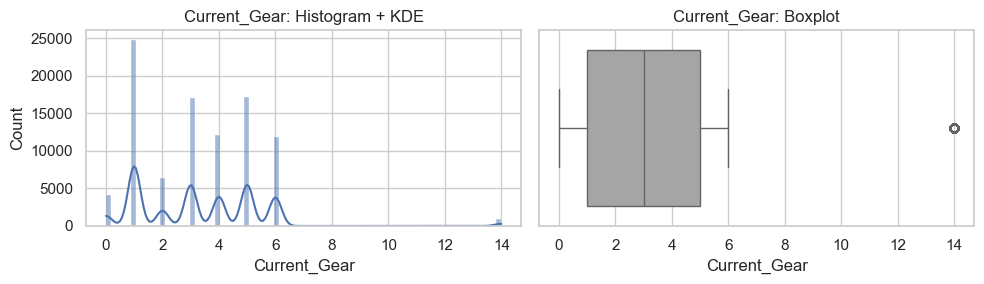

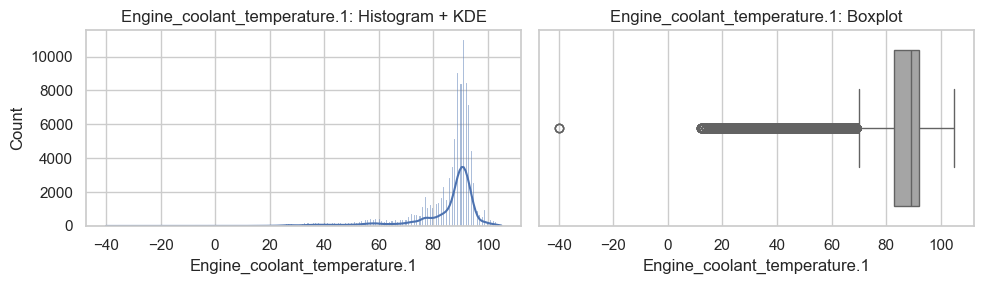

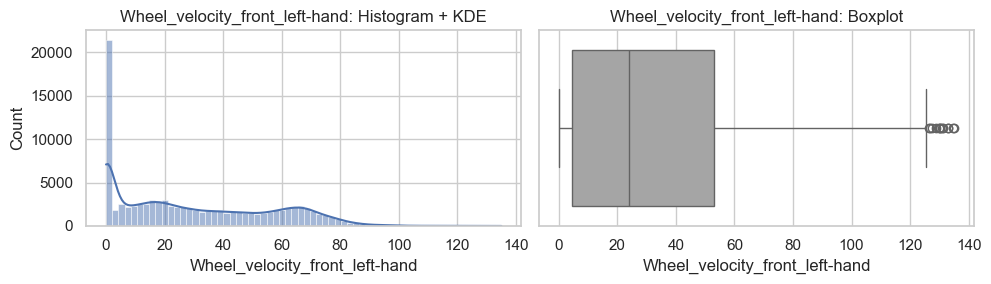

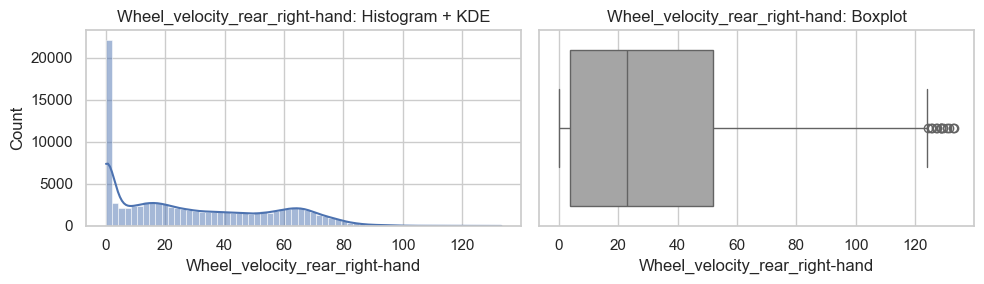

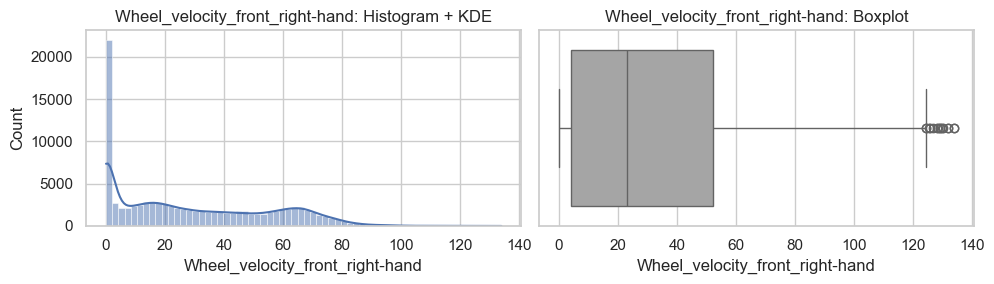

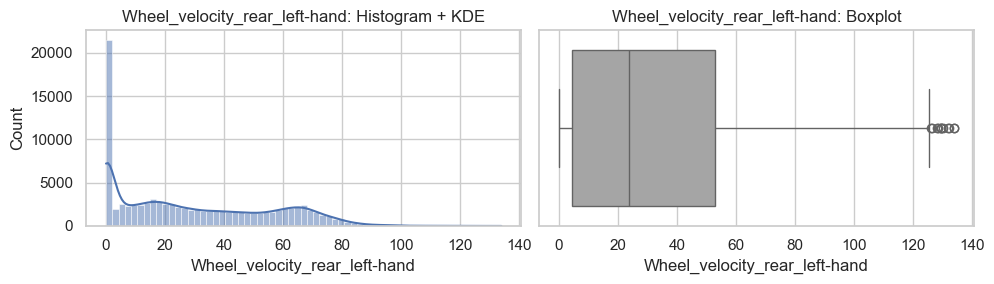

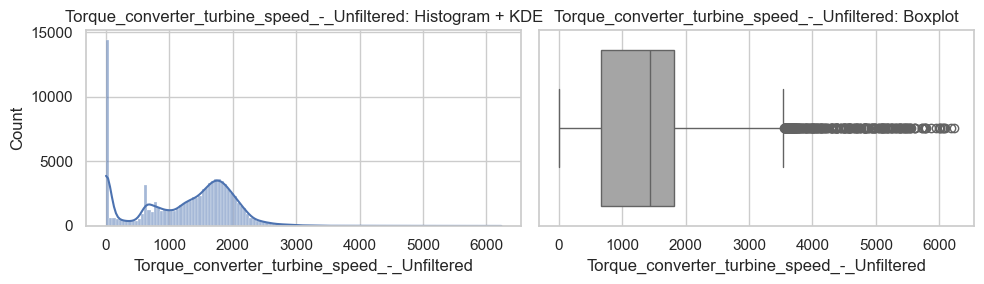

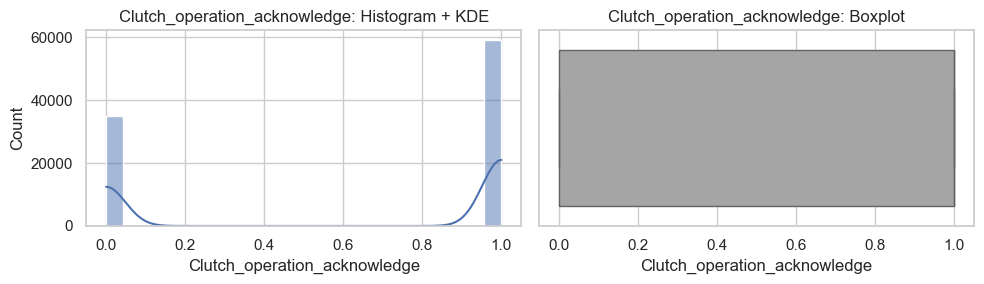

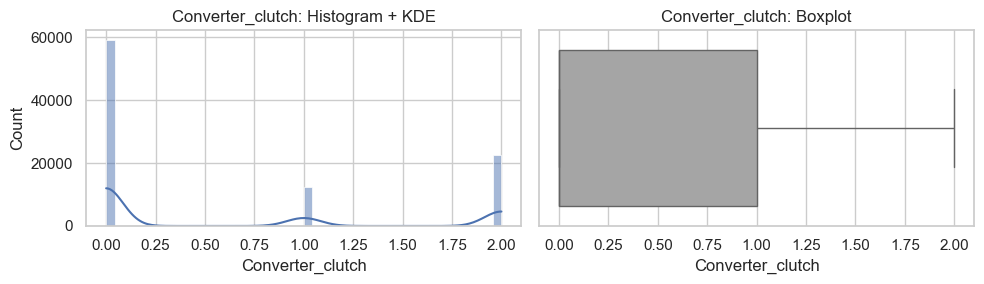

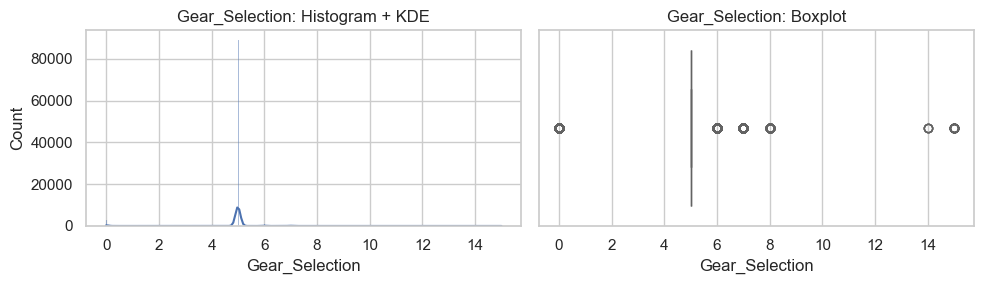

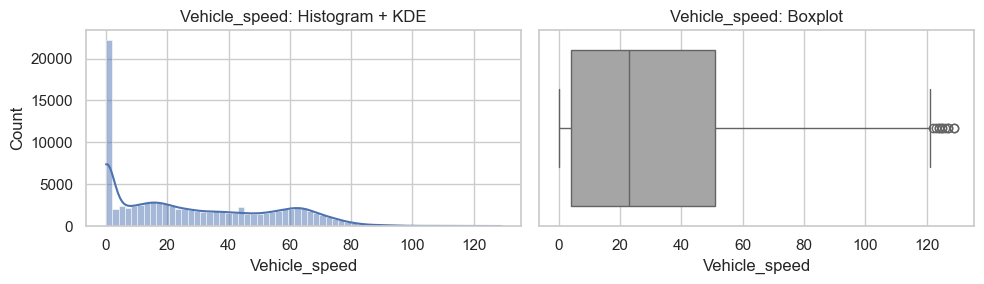

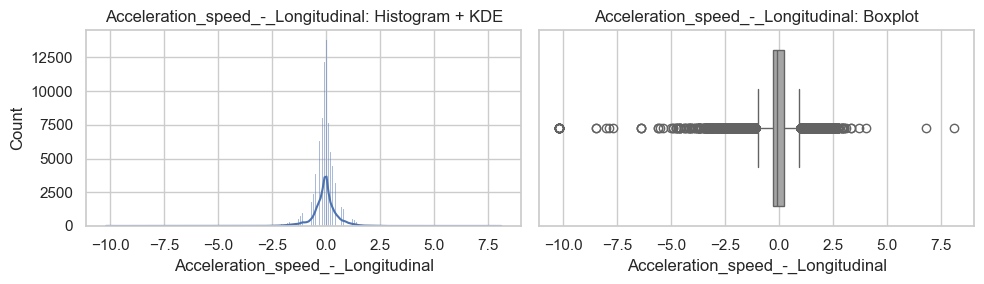

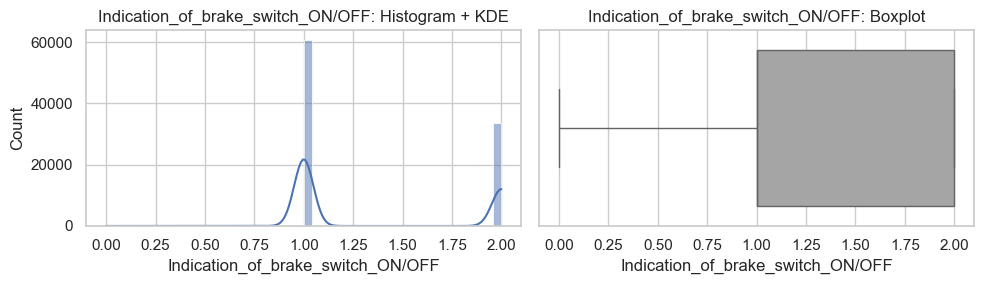

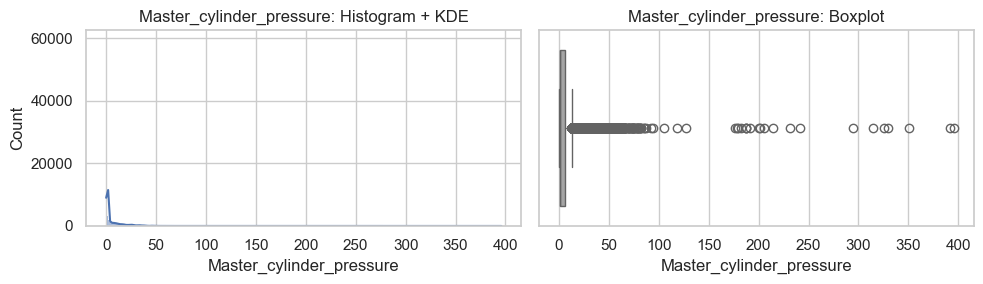

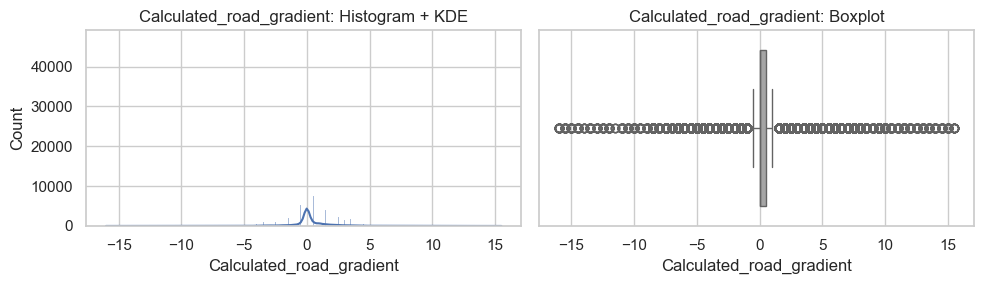

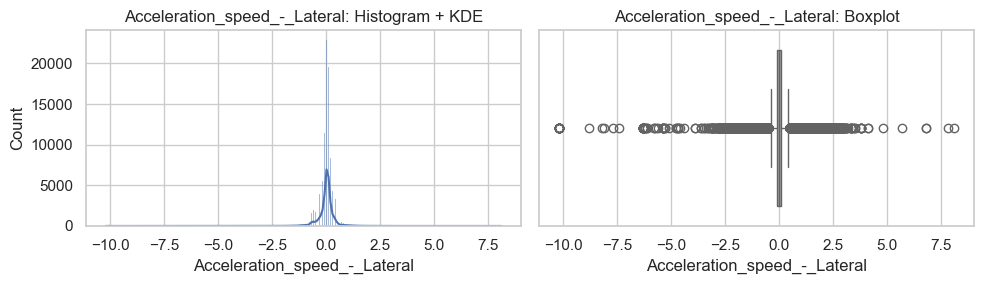

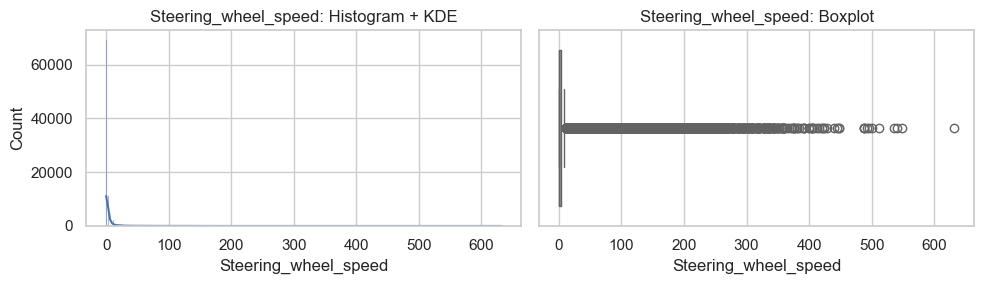

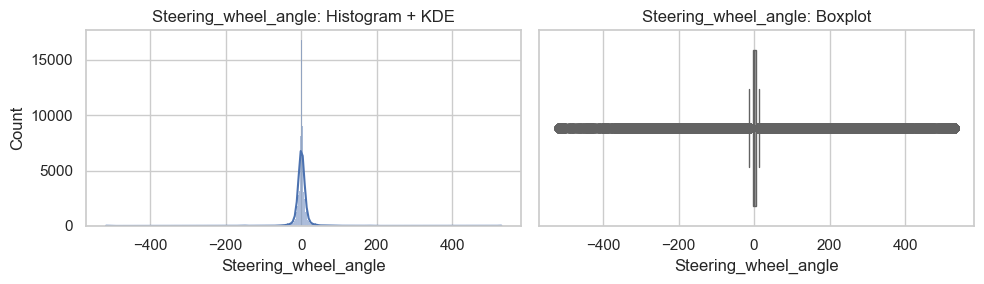

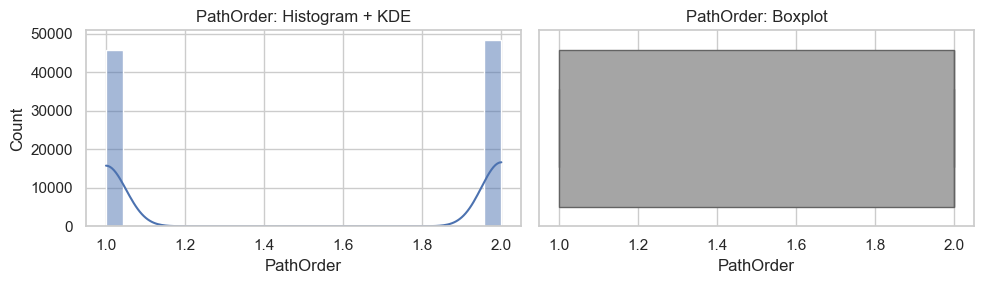

,count,mean,std,min,25%,50%,75%,max,skew,outlier_count,outlier_pct
Fuel_consumption,94380.0,757.000246,761.376214,0.0,320.0,422.40,1036.80,10931.2,2.896893,5363,5.682348
Accelerator_Pedal_value,94380.0,3.718682,8.505756,0.0,0.0,0.00,0.00,99.2,3.640442,23529,24.930070
Throttle_position_signal,94380.0,13.208186,16.262249,0.0,6.6,7.50,12.70,100.0,4.157294,7556,8.005933
Short_Term_Fuel_Trim_Bank1,94380.0,0.122782,3.166412,-15.6,-1.6,0.00,1.60,23.4,0.796784,4742,5.024370
Intake_air_pressure,94380.0,36.853433,27.957584,0.0,4.0,38.00,57.00,178.0,0.214383,49,0.051918
Filtered_Accelerator_Pedal_value,94380.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.0,0.000000,0,0.000000
Absolute_throttle_position,94380.0,19.362277,12.079046,12.5,14.5,15.30,19.20,84.3,4.141676,7393,7.833227
Engine_soacking_time,94380.0,26.795327,73.072712,0.0,1.0,3.00,6.00,255.0,2.715942,9208,9.756304
Inhibition_of_engine_fuel_cut_off,94380.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.0,0.000000,0,0.000000
Engine_in_fuel_cut_off,94380.0,0.067249,0.250455,0.0,0.0,0.00,0.00,1.0,3.455792,6347,6.724942


In [262]:
# Numeric features: histogram + KDE and boxplot
numeric_cols = [col for col in df_eda.select_dtypes(include=np.number).columns if col != 'Class' and col != 'Time(s)']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df_eda[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col}: Histogram + KDE')
    sns.boxplot(x=df_eda[col], ax=axes[1], color='#A5A5A5')
    axes[1].set_title(f'{col}: Boxplot')
    plt.tight_layout()
    plt.show()

# Calculate outliers using IQR method for each column
def calculate_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    return outliers

outlier_counts = {col: calculate_outliers(df_eda[col]) for col in numeric_cols}
outlier_percentages = {col: (count / len(df_eda)) * 100 for col, count in outlier_counts.items()}

# Quick numeric summary to complement plots with outlier info
summary_table = df_eda[numeric_cols].describe().T.assign(
    skew=df_eda[numeric_cols].skew(),
    outlier_count=pd.Series(outlier_counts),
    outlier_pct=pd.Series(outlier_percentages)
)
display(summary_table)

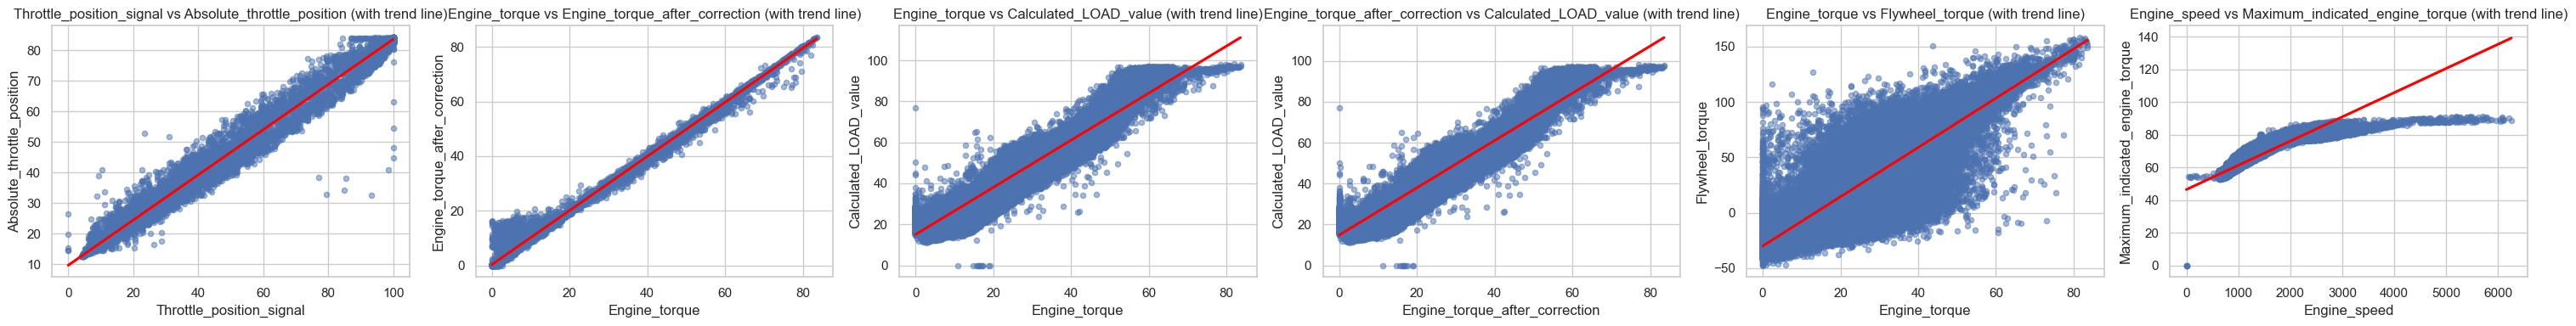

In [263]:

pairs = [
    # Throttle / pedal family
    ('Throttle_position_signal', 'Absolute_throttle_position'),          # ~1.00 (near-duplicate)

    # Torque / load family
    ('Engine_torque', 'Engine_torque_after_correction'),                # ~1.00 (near-duplicate)
    ('Engine_torque', 'Calculated_LOAD_value'),                         # ~0.92
    ('Engine_torque_after_correction', 'Calculated_LOAD_value'),         # ~0.92
    ('Engine_torque', 'Flywheel_torque'),                               # ~0.89
  
    # Engine speed vs torque indicator
    ('Engine_speed', 'Maximum_indicated_engine_torque'),                # ~0.95
]


# Check if all columns exist in df_eda
missing_cols = [col for pair in pairs for col in pair if col not in df_eda.columns]
if missing_cols:
    print(f"Missing columns in df_eda: {missing_cols}")
else:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5*len(pairs), 4))
    for ax, (x, y) in zip(axes, pairs):
        sns.regplot(data=df_eda, x=x, y=y, scatter_kws={'s': 20, 'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax)
        ax.set_title(f'{x} vs {y} (with trend line)')
    plt.tight_layout()
    plt.show()

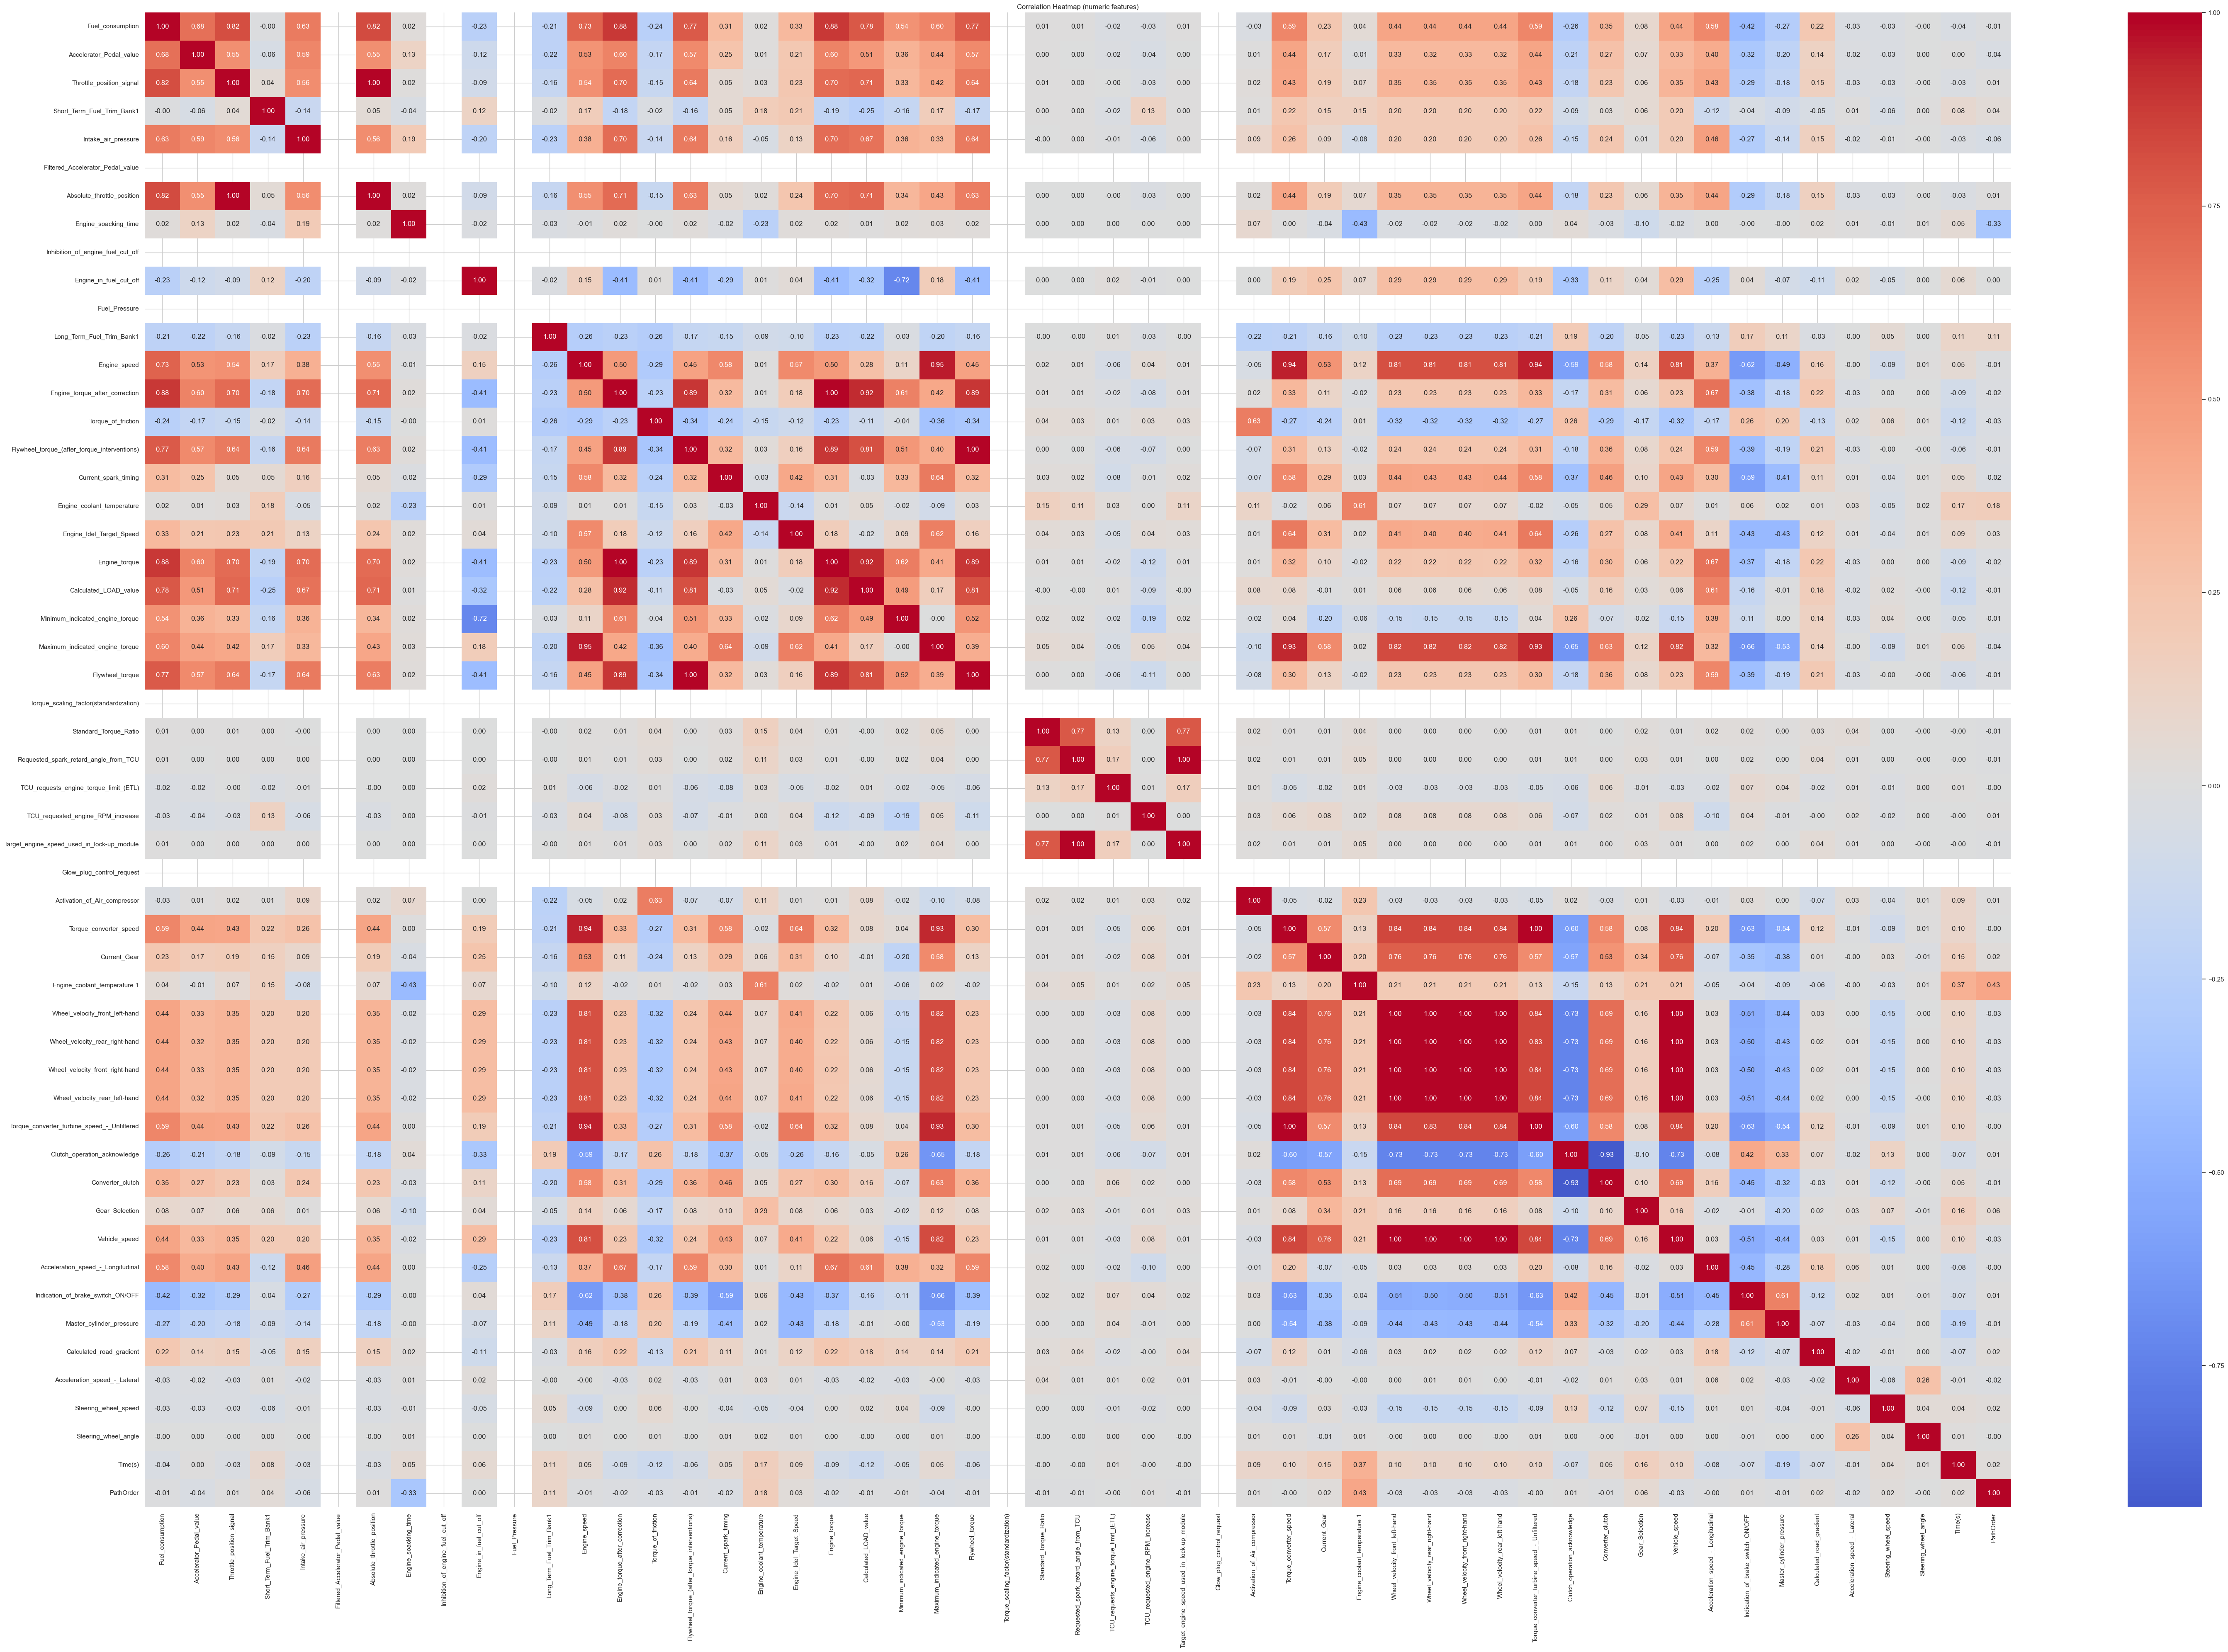

In [264]:
num_df = df_eda.select_dtypes(include='number')
plt.figure(figsize=(60, 40))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()

## now we can start with changing the data 
Remove non-informative features (closed to 0 var and same values features) cz they do give any usfule infos
Handle highly correlated features (we can use random forest that is good with correlation or keep one feature from ones that are very correlated)
Outlier handling
Feature scaling


# 🧹 Data Cleaning & Quality Assurance

This notebook implements comprehensive data cleaning following the lecture framework:
- **A) Duplicates**: Identify and remove duplicate records
- **B) Missing Values**: Handle NaN and invalid entries
- **C) Outliers**: Detect and manage anomalous values using statistical methods
- **D) Noise**: Smooth noisy data and handle data quality issues

**Output**: A cleaned dataset saved to `data/cleaned/` and a detailed change record.


## Initial Data Assessment

In [265]:
print("="*80)
print("INITIAL DATA ASSESSMENT")
print("="*80)

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst few rows:")
display(df.head(3))

INITIAL DATA ASSESSMENT

Dataset Shape: 94380 rows × 54 columns

Column Names:
['Fuel_consumption', 'Accelerator_Pedal_value', 'Throttle_position_signal', 'Short_Term_Fuel_Trim_Bank1', 'Intake_air_pressure', 'Filtered_Accelerator_Pedal_value', 'Absolute_throttle_position', 'Engine_soacking_time', 'Inhibition_of_engine_fuel_cut_off', 'Engine_in_fuel_cut_off', 'Fuel_Pressure', 'Long_Term_Fuel_Trim_Bank1', 'Engine_speed', 'Engine_torque_after_correction', 'Torque_of_friction', 'Flywheel_torque_(after_torque_interventions)', 'Current_spark_timing', 'Engine_coolant_temperature', 'Engine_Idel_Target_Speed', 'Engine_torque', 'Calculated_LOAD_value', 'Minimum_indicated_engine_torque', 'Maximum_indicated_engine_torque', 'Flywheel_torque', 'Torque_scaling_factor(standardization)', 'Standard_Torque_Ratio', 'Requested_spark_retard_angle_from_TCU', 'TCU_requests_engine_torque_limit_(ETL)', 'TCU_requested_engine_RPM_increase', 'Target_engine_speed_used_in_lock-up_module', 'Glow_plug_control_request'

,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,Fuel_Pressure,Long_Term_Fuel_Trim_Bank1,Engine_speed,Engine_torque_after_correction,Torque_of_friction,Flywheel_torque_(after_torque_interventions),Current_spark_timing,Engine_coolant_temperature,Engine_Idel_Target_Speed,Engine_torque,Calculated_LOAD_value,Minimum_indicated_engine_torque,Maximum_indicated_engine_torque,Flywheel_torque,Torque_scaling_factor(standardization),...,Target_engine_speed_used_in_lock-up_module,Glow_plug_control_request,Activation_of_Air_compressor,Torque_converter_speed,Current_Gear,Engine_coolant_temperature.1,Wheel_velocity_front_left-hand,Wheel_velocity_rear_right-hand,Wheel_velocity_front_right-hand,Wheel_velocity_rear_left-hand,Torque_converter_turbine_speed_-_Unfiltered,Clutch_operation_acknowledge,Converter_clutch,Gear_Selection,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,5.2,0.0,33,0,13.3,3,0,0,0,-0.8,929,5.5,9.0,-5.9,-8.6,95,650,5.5,23.9,2.0,58.2,-5.9,230,...,3040,0,0,939.3,0,87,0.0,0.0,0.0,0.0,935.5,1,0,0,0,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,0,13.7,3,0,0,0,-0.8,726,7.0,7.8,1.7,-11.3,95,670,7.0,30.6,2.0,53.9,1.8,230,...,3040,0,0,710.0,0,87,0.0,0.0,0.0,0.0,709.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,0.0,41,0,13.7,3,0,0,0,-0.8,685,7.0,7.4,-3.0,-12.8,95,670,7.0,31.8,2.0,53.1,-2.8,230,...,3040,0,0,663.3,0,87,0.0,0.0,0.0,0.0,663.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1


## A) DUPLICATES - Identify and Remove Duplicate Records


In [266]:



print("\n" + "="*80)
print("3A) DUPLICATES ANALYSIS")
print("="*80)

initial_rows = len(df)

# Check for complete duplicates (all columns identical)
complete_dupes = df.duplicated(keep=False).sum()
print(f"\n Complete Duplicates (all columns): {complete_dupes}")

if complete_dupes > 0:
    print("\nSample of complete duplicates:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6))

# Check for duplicates considering key identifiers (exclude Time and PathOrder)
key_cols = [col for col in df.columns if col not in ['Time(s)', 'PathOrder']]
partial_dupes = df.duplicated(subset=key_cols, keep=False).sum()
print(f"\n Duplicates (excluding Time & PathOrder): {partial_dupes}")

# Remove complete duplicates (keep='first')
df_no_dupes = df.drop_duplicates(keep='first')
dupes_removed = initial_rows - len(df_no_dupes)
print(f"\n Duplicates removed: {dupes_removed}")
print(f"   Rows after deduplication: {len(df_no_dupes)}")
# which rows are duplicates ?
if dupes_removed > 0:
    print("\nSample of duplicates removed:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(6))
#  Duplicates in rows or colomns have been handled. ?
df = df_no_dupes
print("\n✓ Duplicate analysis and removal complete.")
print("="*80)



3A) DUPLICATES ANALYSIS

 Complete Duplicates (all columns): 0

 Duplicates (excluding Time & PathOrder): 2

 Duplicates removed: 0
   Rows after deduplication: 94380

✓ Duplicate analysis and removal complete.


    ** No duplicate records were detected.

## B) MISSING VALUES - Analyze and Handle NaN

In [267]:
print("\n" + "="*80)
print("3B) MISSING VALUES ANALYSIS")
print("="*80)

# Count missing values
missing_count = df_no_dupes.isnull().sum()
missing_pct = (missing_count / len(df_no_dupes)) * 100
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_%': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)

if len(missing_df) > 0:
    print(f"\nColumns with missing values ({len(missing_df)}):")
    display(missing_df)
else:
    print("\n✓ No missing values found!")

total_missing = df_no_dupes.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

# Create df_no_missing for next stage (no rows/columns dropped since no missing values)
df_no_missing = df_no_dupes.copy()
print(f"\n✓ Rows after missing value handling: {len(df_no_missing)}")


3B) MISSING VALUES ANALYSIS

✓ No missing values found!

Total missing values: 0

✓ Rows after missing value handling: 94380


     ** No missing values found

## C) OUTLIERS - Detect and Visualize
* Here we are focusing on the imposible values , not Noise since they are the goal of this study

In [268]:
print("\n" + "="*80)
print("3C) OUTLIERS DETECTION & ANALYSIS")
print("="*80)

# Get numeric columns (exclude Time, PathOrder, Class for now)

numeric_cols = df_no_missing.select_dtypes(include=[np.number]).columns.tolist()

exclude_cols = ['Time(s)', 'PathOrder']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"\n Numeric columns for analysis: {len(numeric_cols)}")
print(numeric_cols[:10], "...")  # Show first 10

# Calculate outliers using IQR method
outlier_summary = []
for col in numeric_cols:
    Q1 = df_no_missing[col].quantile(0.25)
    Q3 = df_no_missing[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (df_no_missing[col] < lower_bound) | (df_no_missing[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = (outlier_count / len(df_no_missing)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_%': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_%', ascending=False)
print("\n Top 10 columns with most outliers (IQR method):")
display(outlier_df.head(10))


3C) OUTLIERS DETECTION & ANALYSIS

 Numeric columns for analysis: 51
['Fuel_consumption', 'Accelerator_Pedal_value', 'Throttle_position_signal', 'Short_Term_Fuel_Trim_Bank1', 'Intake_air_pressure', 'Filtered_Accelerator_Pedal_value', 'Absolute_throttle_position', 'Engine_soacking_time', 'Inhibition_of_engine_fuel_cut_off', 'Engine_in_fuel_cut_off'] ...

 Top 10 columns with most outliers (IQR method):


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
47,Calculated_road_gradient,0.0,0.5,0.5,-0.75,1.25,28728,30.438652
1,Accelerator_Pedal_value,0.0,0.0,0.0,0.00,0.00,23529,24.930070
50,Steering_wheel_angle,-2.6,4.0,6.6,-12.50,13.90,15637,16.568129
46,Master_cylinder_pressure,1.0,5.9,4.9,-6.35,13.25,13757,14.576181
48,Acceleration_speed_-_Lateral,-0.1,0.1,0.2,-0.40,0.40,12336,13.070566
21,Minimum_indicated_engine_torque,2.0,2.3,0.3,1.55,2.75,11823,12.527018
31,Activation_of_Air_compressor,1.0,1.0,0.0,1.00,1.00,10327,10.941937
34,Engine_coolant_temperature.1,83.0,92.0,9.0,69.50,105.50,10079,10.679169
49,Steering_wheel_speed,0.0,4.0,4.0,-6.00,10.00,9579,10.149396
7,Engine_soacking_time,1.0,6.0,5.0,-6.50,13.50,9208,9.756304



Boxplot visualizations for top outlier columns:


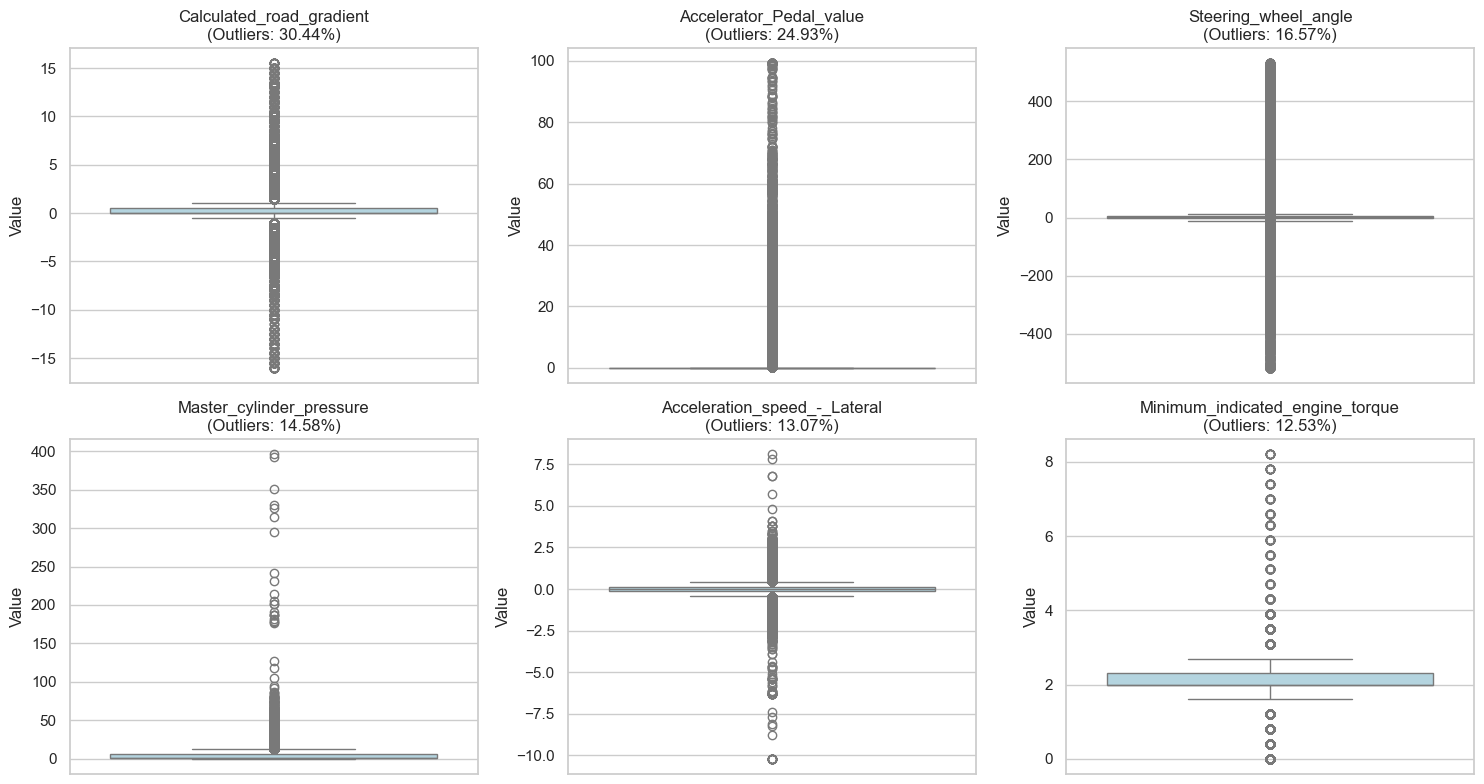

✓ Boxplots generated for visual inspection


In [269]:
# Visualize top 6 features with highest outlier percentages
print("\nBoxplot visualizations for top outlier columns:")

top_outlier_cols = outlier_df.head(6)['Column'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(top_outlier_cols):
    sns.boxplot(y=df_no_missing[col], ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'{col}\n(Outliers: {outlier_df[outlier_df["Column"]==col]["Outlier_%"].values[0]:.2f}%)')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

print("✓ Boxplots generated for visual inspection")

In [270]:
# Decision: Analyze outlier context
print("\n" + "-"*80)
print("OUTLIER HANDLING DECISION")
print("-"*80)

print("\nContext Analysis:")
print("   - Dataset: Driving data from 10 drivers")
print("   - Goal: Driving assessment and pattern discovery")
print("   - Consideration: Outliers could represent:")
print("       • Extreme driving behaviors (valid for analysis)")
print("       • Measurement errors/sensor noise (invalid)")
print("       • Different driving conditions (valid context)")

print("\nSTRATEGY: Use Winsorization (capping) instead of removal:")
print("   - Cap outliers at 95th/5th percentiles")
print("   - Preserves extreme but valid driving behaviors")
print("   - Reduces impact of potential measurement errors")
print("   - Maintains data for pattern discovery")

# Apply Winsorization (cap at 5th and 95th percentiles)
df_winsorized = df_no_missing.copy()
winsor_summary = []

for col in numeric_cols:
    p5 = df_winsorized[col].quantile(0.05)
    p95 = df_winsorized[col].quantile(0.95)
    
    values_below_p5 = (df_winsorized[col] < p5).sum()
    values_above_p95 = (df_winsorized[col] > p95).sum()
    values_capped = values_below_p5 + values_above_p95
    
    df_winsorized[col] = df_winsorized[col].clip(lower=p5, upper=p95)
    
    winsor_summary.append({
        'Column': col,
        'P5': p5,
        'P95': p95,
        'Capped_Below_P5': values_below_p5,
        'Capped_Above_P95': values_above_p95,
        'Total_Capped': values_capped
    })

winsor_df = pd.DataFrame(winsor_summary).sort_values('Total_Capped', ascending=False)
print("\nWinsorization applied:")
print(f"   Total values capped: {winsor_df['Total_Capped'].sum():,}")
print("\n   Top 5 columns with capped values:")
display(winsor_df[winsor_df['Total_Capped'] > 0].head(5))


--------------------------------------------------------------------------------
OUTLIER HANDLING DECISION
--------------------------------------------------------------------------------

Context Analysis:
   - Dataset: Driving data from 10 drivers
   - Goal: Driving assessment and pattern discovery
   - Consideration: Outliers could represent:
       • Extreme driving behaviors (valid for analysis)
       • Measurement errors/sensor noise (invalid)
       • Different driving conditions (valid context)

STRATEGY: Use Winsorization (capping) instead of removal:
   - Cap outliers at 95th/5th percentiles
   - Preserves extreme but valid driving behaviors
   - Reduces impact of potential measurement errors
   - Maintains data for pattern discovery

Winsorization applied:
   Total values capped: 237,005

   Top 5 columns with capped values:


,Column,P5,P95,Capped_Below_P5,Capped_Above_P95,Total_Capped
50,Steering_wheel_angle,-23.5,24.3,4704,4713,9417
6,Absolute_throttle_position,14.1,36.1,4705,4711,9416
15,Flywheel_torque_(after_torque_interventions),-31.1,95.6,4691,4696,9387
23,Flywheel_torque,-31.2,95.8,4688,4693,9381
0,Fuel_consumption,38.4,2227.2,4581,4672,9253


* we used capping in order to reduce the effect of noise and outliers without deleting data m since they r our target here


## D) NOISE - Smooth and Validate Data Quality

In [271]:
print("\n" + "="*80)
print("3D) NOISE REDUCTION & DATA QUALITY")
print("="*80)

df_cleaned = df_winsorized.copy()

# 1. Handle zero/constant values that might be noise
print("\nNoise Detection:")
print("   Checking for suspicious zero values and constant features...")

noise_report = []
n_rows = len(df_cleaned)
for col in numeric_cols:
    s = df_cleaned[col]
    zero_count = int((s == 0).sum())
    zero_pct = (zero_count / n_rows) * 100 if n_rows else 0.0

    unique_values = int(s.nunique(dropna=True))
    unique_pct = unique_values / n_rows if n_rows else 0.0

    variance = float(s.var())
    value_range = float(s.max() - s.min())

    # relative variance normalized by squared range to be scale-invariant
    rel_var = variance / (value_range**2 + 1e-12)

    noise_report.append({
        'Column': col,
        'Zeros': zero_count,
        'Zero_%': zero_pct,
        'Unique_Values': unique_values,
        'Unique_%': unique_pct,
        'Variance': variance,
        'Range': value_range,
        'Rel_Var': rel_var
    })

noise_df = pd.DataFrame(noise_report).sort_values('Zero_%', ascending=False)

print("\n   Top columns with high zero values:")
display(noise_df.head(10))

# Automatically detect zero-heavy columns (adjust threshold if needed)
zero_threshold_pct = 99.0  # percent of rows that are zero -> consider as noise/uninformative
zero_heavy_cols = noise_df[noise_df['Zero_%'] >= zero_threshold_pct]['Column'].tolist()
if zero_heavy_cols:
    print(f"\n✓ Detected zero-heavy columns (>= {zero_threshold_pct}% zeros): {zero_heavy_cols}")
else:
    # also show any fully-constant columns (100% identical)
    all_const_cols = noise_df[noise_df['Range'] == 0]['Column'].tolist()
    if all_const_cols:
        print(f"\n✓ Detected fully-constant columns: {all_const_cols}")
        zero_heavy_cols = all_const_cols
    else:
        print(f"\n✓ No zero-heavy columns detected at threshold {zero_threshold_pct}%")

print("\n   Columns with very low variance (near-constant):")
# Improved low-variance detection: exact-constant, tiny absolute variance, very small relative variance, or very few unique values.
low_var_mask = (
    (noise_df['Range'] == 0) |
    (noise_df['Variance'].abs() < 1e-8) |
    (noise_df['Rel_Var'] < 1e-6) |
    (noise_df['Unique_%'] < 0.01)  # less than 1% distinct values
)
low_var = noise_df[low_var_mask].sort_values(['Rel_Var','Variance','Unique_%'])
display(low_var.head(50))

# ...existing code...
low_var_all = low_var['Column'].tolist()

# Protect key driving-features from accidental removal
protected = {
    'Vehicle_speed' ,"Acceleration_speed_-_Longitudinal",
    "Acceleration_speed_-_Lateral",
    "Steering_wheel_angle",
    "Steering_wheel_speed",
    "Master_cylinder_pressure",
    "Indication_of_brake_switch_ON/OFF"}

# remove only top N lowest-variance features (excluding protected)
top_n = 12
low_var_candidates = [c for c in low_var['Column'].tolist() if c not in protected]
low_var_to_drop = low_var_candidates[:top_n]

# If any zero-heavy columns are protected, keep them
zero_heavy_unprotected = [c for c in zero_heavy_cols if c not in protected]

# Combine detected columns to drop (no hardcoded feature list)
cols_to_drop = sorted(set(zero_heavy_unprotected + low_var_to_drop))

if cols_to_drop:
    df_cleaned = df_cleaned.drop(columns=cols_to_drop, errors='ignore')
    numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]
    print(f"\n✓ Dropped detected uninformative columns (zero-heavy unprotected + top {top_n} low-var): {cols_to_drop}")
    if low_var_all:
        protected_found = [c for c in low_var_all if c in protected]
        if protected_found:
            print(f"   Protected (not dropped): {protected_found}")
        print(f"   Candidates (all low-var): {low_var_all[:50]}")
else:
    print("\n✓ No uninformative columns detected to drop")
print(df_cleaned.shape)
# ...existing code...



3D) NOISE REDUCTION & DATA QUALITY

Noise Detection:
   Checking for suspicious zero values and constant features...

   Top columns with high zero values:


,Column,Zeros,Zero_%,Unique_Values,Unique_%,Variance,Range,Rel_Var
10,Fuel_Pressure,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
8,Inhibition_of_engine_fuel_cut_off,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
5,Filtered_Accelerator_Pedal_value,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
28,TCU_requested_engine_RPM_increase,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
30,Glow_plug_control_request,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
9,Engine_in_fuel_cut_off,88033,93.275058,2,0.000021,0.062728,1.0,0.062728
1,Accelerator_Pedal_value,70851,75.069930,54,0.000572,41.287173,20.7,0.096355
49,Steering_wheel_speed,69229,73.351346,8,0.000085,49.566260,28.0,0.063222
41,Converter_clutch,59222,62.748464,3,0.000032,0.717871,2.0,0.179468
47,Calculated_road_gradient,46758,49.542276,13,0.000138,1.823611,6.0,0.050656



✓ Detected zero-heavy columns (>= 99.0% zeros): ['Fuel_Pressure', 'Inhibition_of_engine_fuel_cut_off', 'Filtered_Accelerator_Pedal_value', 'TCU_requested_engine_RPM_increase', 'Glow_plug_control_request']

   Columns with very low variance (near-constant):


,Column,Zeros,Zero_%,Unique_Values,Unique_%,Variance,Range,Rel_Var
10,Fuel_Pressure,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
8,Inhibition_of_engine_fuel_cut_off,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
5,Filtered_Accelerator_Pedal_value,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
28,TCU_requested_engine_RPM_increase,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
30,Glow_plug_control_request,94380,100.000000,1,0.000011,0.000000,0.0,0.000000
24,Torque_scaling_factor(standardization),0,0.000000,1,0.000011,0.000000,0.0,0.000000
25,Standard_Torque_Ratio,0,0.000000,1,0.000011,0.000000,0.0,0.000000
26,Requested_spark_retard_angle_from_TCU,0,0.000000,1,0.000011,0.000000,0.0,0.000000
27,TCU_requests_engine_torque_limit_(ETL),0,0.000000,1,0.000011,0.000000,0.0,0.000000
29,Target_engine_speed_used_in_lock-up_module,0,0.000000,1,0.000011,0.000000,0.0,0.000000



✓ Dropped detected uninformative columns (zero-heavy unprotected + top 12 low-var): ['Engine_coolant_temperature', 'Filtered_Accelerator_Pedal_value', 'Fuel_Pressure', 'Gear_Selection', 'Glow_plug_control_request', 'Inhibition_of_engine_fuel_cut_off', 'Requested_spark_retard_angle_from_TCU', 'Standard_Torque_Ratio', 'TCU_requested_engine_RPM_increase', 'TCU_requests_engine_torque_limit_(ETL)', 'Target_engine_speed_used_in_lock-up_module', 'Torque_scaling_factor(standardization)']
   Protected (not dropped): ['Steering_wheel_angle', 'Acceleration_speed_-_Longitudinal', 'Acceleration_speed_-_Lateral', 'Steering_wheel_speed', 'Master_cylinder_pressure', 'Vehicle_speed', 'Indication_of_brake_switch_ON/OFF']
   Candidates (all low-var): ['Fuel_Pressure', 'Inhibition_of_engine_fuel_cut_off', 'Filtered_Accelerator_Pedal_value', 'TCU_requested_engine_RPM_increase', 'Glow_plug_control_request', 'Torque_scaling_factor(standardization)', 'Standard_Torque_Ratio', 'Requested_spark_retard_angle_fro

In [272]:
# ...existing code...
# 2. Detect near-duplicate columns (high correlation)
print("\nNear-Duplicate Features (High Correlation):")

# Calculate correlation matrix
corr_matrix = df_cleaned[numeric_cols].corr().abs()

# Find highly correlated pairs (excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(f"\n   Found {len(high_corr_df)} highly correlated pairs (>0.95):")
    display(high_corr_df)

    # Protect these features from being removed
    protected = {'Vehicle_speed' ,
    "Acceleration_speed_-_Longitudinal",
    "Acceleration_speed_-_Lateral",
    "Steering_wheel_angle",
    "Steering_wheel_speed",
    "Master_cylinder_pressure",
    "Indication_of_brake_switch_ON/OFF"}

    # Choose removals while never dropping protected features.
    cols_to_drop = set()
    for _, row in high_corr_df.iterrows():
        f1 = row['Feature_1']
        f2 = row['Feature_2']
        # skip if already decided to drop one of them
        if f1 in cols_to_drop or f2 in cols_to_drop:
            continue
        # if both protected -> skip
        if f1 in protected and f2 in protected:
            continue
        # drop the unprotected one (prefer keeping protected)
        if f2 in protected and f1 not in protected:
            cols_to_drop.add(f1)
        elif f1 in protected and f2 not in protected:
            cols_to_drop.add(f2)
        else:
            # neither protected -> keep original strategy (drop Feature_2)
            cols_to_drop.add(f2)

    cols_to_drop = sorted(cols_to_drop)
    if cols_to_drop:
        df_cleaned = df_cleaned.drop(columns=cols_to_drop, errors='ignore')
        numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]
        print(f"\n✓ Dropped highly correlated features (protected kept): {cols_to_drop}")
    else:
        print("\n✓ No non-protected highly correlated features to drop")
else:
    print("   No near-duplicate features found")

print(df_cleaned.shape)
# ...existing code...


Near-Duplicate Features (High Correlation):

   Found 15 highly correlated pairs (>0.95):


,Feature_1,Feature_2,Correlation
4,Torque_converter_speed,Torque_converter_turbine_speed_-_Unfiltered,0.999998
7,Wheel_velocity_front_left-hand,Wheel_velocity_rear_left-hand,0.999990
9,Wheel_velocity_rear_right-hand,Wheel_velocity_front_right-hand,0.999969
13,Wheel_velocity_front_right-hand,Vehicle_speed,0.999839
6,Wheel_velocity_front_left-hand,Wheel_velocity_front_right-hand,0.999837
10,Wheel_velocity_rear_right-hand,Wheel_velocity_rear_left-hand,0.999830
5,Wheel_velocity_front_left-hand,Wheel_velocity_rear_right-hand,0.999829
11,Wheel_velocity_rear_right-hand,Vehicle_speed,0.999826
12,Wheel_velocity_front_right-hand,Wheel_velocity_rear_left-hand,0.999825
8,Wheel_velocity_front_left-hand,Vehicle_speed,0.999822



✓ Dropped highly correlated features (protected kept): ['Absolute_throttle_position', 'Engine_torque', 'Flywheel_torque', 'Maximum_indicated_engine_torque', 'Torque_converter_turbine_speed_-_Unfiltered', 'Wheel_velocity_front_left-hand', 'Wheel_velocity_front_right-hand', 'Wheel_velocity_rear_left-hand', 'Wheel_velocity_rear_right-hand']
(94380, 33)


In [273]:
# 3. Data type validation
print("\n✓ Data Type & Format Validation:")
print(f"   Numeric columns: {len(numeric_cols)}")
print(f"   Object columns: {df_cleaned.select_dtypes(include='object').shape[1]}")

# Check for categorical data
categorical_cols = df_cleaned.select_dtypes(include='object').columns.tolist()
print(f"\n   Categorical columns: {categorical_cols}")
for col in categorical_cols:
    print(f"      - {col}: {df_cleaned[col].nunique()} unique values")
    print(f"        Values: {df_cleaned[col].unique().tolist()}")


✓ Data Type & Format Validation:
   Numeric columns: 30
   Object columns: 1

   Categorical columns: ['Class']
      - Class: 10 unique values
        Values: ['A', 'D', 'B', 'C', 'I', 'J', 'H', 'G', 'F', 'E']


## Data Quality Summary & Save Cleaned Data

In [274]:
print("\n" + "="*80)
print("DATA CLEANING SUMMARY")
print("="*80)

print(f"\nBEFORE CLEANING:")
print(f"   Rows: {initial_rows:,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Shape: {df.shape}")

print(f"\nCLEANING STEPS APPLIED:")
print(f"   1. Duplicates removed: {dupes_removed}")
print(f"   2. Missing values: Analyzed (no rows/cols dropped)")
print(f"   3. Outliers: Winsorized {winsor_df['Total_Capped'].sum():,} values")
print(f"   4. Noise: Detected high-correlation features and zero-heavy columns")

print(f"\nAFTER CLEANING:")
print(f"   Rows: {len(df_cleaned):,}")
print(f"   Columns: {df_cleaned.shape[1]}")
print(f"   Shape: {df_cleaned.shape}")
print(f"   Rows removed: {initial_rows - len(df_cleaned):,} ({((initial_rows - len(df_cleaned))/initial_rows)*100:.2f}%)")

print(f"\n✓ DATA QUALITY METRICS:")
print(f"   Missing values: {df_cleaned.isnull().sum().sum()} (0.00%)")
print(f"   Duplicates: {df_cleaned.duplicated().sum()}")
print(f"   Data types valid: ✓")


DATA CLEANING SUMMARY

BEFORE CLEANING:
   Rows: 94,380
   Columns: 54
   Shape: (94380, 54)

CLEANING STEPS APPLIED:
   1. Duplicates removed: 0
   2. Missing values: Analyzed (no rows/cols dropped)
   3. Outliers: Winsorized 237,005 values
   4. Noise: Detected high-correlation features and zero-heavy columns

AFTER CLEANING:
   Rows: 94,380
   Columns: 33
   Shape: (94380, 33)
   Rows removed: 0 (0.00%)

✓ DATA QUALITY METRICS:
   Missing values: 0 (0.00%)
   Duplicates: 0
   Data types valid: ✓


In [275]:
print(f"\nSaving cleaned data...")
CLEANED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df_cleaned.to_csv(CLEANED_DATA_PATH, index=False)
print(f"✓ Cleaned data saved to: {CLEANED_DATA_PATH}")
print(f"  File size: {CLEANED_DATA_PATH.stat().st_size / 1024 / 1024:.2f} MB")


Saving cleaned data...
✓ Cleaned data saved to: C:\Users\idris\Modules\3rd\S1\DM\CDTA\CDTA-AI-Model-Development-For-Driving-Assessment\data\cleaned\Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J)_cleaned.csv
  File size: 11.06 MB


## Final Verification

In [276]:
print("\n" + "="*80)
print("FINAL VERIFICATION")
print("="*80)

# Verify cleaned data
df_verify = pd.read_csv(CLEANED_DATA_PATH)
print(f"\nCleaned dataset verified:")
print(f"   Shape: {df_verify.shape}")
print(f"   Missing values: {df_verify.isnull().sum().sum()}")
print(f"   Duplicates: {df_verify.duplicated().sum()}")
print(f"\nFiles generated:")
print(f"   - {CLEANED_DATA_PATH}")
print(f"   - {CHANGE_LOG_PATH}")

print(f"\nDATA CLEANING COMPLETE!")
print(f"   Ready for feature engineering and modeling.")

df_verify.head()


FINAL VERIFICATION

Cleaned dataset verified:
   Shape: (94380, 33)
   Missing values: 0
   Duplicates: 0

Files generated:
   - C:\Users\idris\Modules\3rd\S1\DM\CDTA\CDTA-AI-Model-Development-For-Driving-Assessment\data\cleaned\Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J)_cleaned.csv
   - C:\Users\idris\Modules\3rd\S1\DM\CDTA\CDTA-AI-Model-Development-For-Driving-Assessment\results\data_cleaning_change_log.txt

DATA CLEANING COMPLETE!
   Ready for feature engineering and modeling.


,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Engine_soacking_time,Engine_in_fuel_cut_off,Long_Term_Fuel_Trim_Bank1,Engine_speed,Engine_torque_after_correction,Torque_of_friction,Flywheel_torque_(after_torque_interventions),Current_spark_timing,Engine_Idel_Target_Speed,Calculated_LOAD_value,Minimum_indicated_engine_torque,Activation_of_Air_compressor,Torque_converter_speed,Current_Gear,Engine_coolant_temperature.1,Clutch_operation_acknowledge,Converter_clutch,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,6.1,0.0,33,3,0,0.8,929,5.5,9.4,-5.9,-5.6,670,23.9,2.0,0,939.3,1,87,1,0,0,-1.1,1,26.7,0.0,-0.6,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,3,0,0.8,726,7.0,9.4,1.7,-5.6,670,30.6,2.0,0,710.0,1,87,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,6.1,0.0,41,3,0,0.8,685,7.0,9.4,-3.0,-5.6,670,31.8,2.0,0,663.3,1,87,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,6.1,0.0,38,3,0,0.8,675,7.0,9.4,-1.3,-5.6,670,29.0,2.0,0,652.5,1,87,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,6.1,0.0,40,3,0,0.8,716,8.2,11.3,-15.6,-5.6,670,30.2,2.0,1,692.5,1,87,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1


# Labeling part 



**FEATURE SELECTION**


our goal in this step is to reduce the dataset to only features that describe driving behavior


**How would we choose features**

we will choose features based on physics & driving logic



**Principle 1 :**  

| Behavior           | What causes it               |
| ------------------ | ---------------------------- |
| Harsh braking      | Sudden negative acceleration |
| Overspeeding       | High vehicle speed           |
| Aggressive turning | High lateral acceleration    |
| Unsafe steering    | Sharp steering angle changes |
| Panic braking      | Brake pressure               |



we keep features that directly measure these actions.


**Principle 2 :**

We remove features that:



*   Do not change with driving style
*   Describe engine internals only
*   Are identifiers (driver ID)

**Final selected features**

| Feature                             | Why                          |
| ----------------------------------- | ---------------------------- |
| `Vehicle_speed`                     | Overspeeding                 |
| `Acceleration_speed_-_Longitudinal` | Harsh braking / acceleration |
| `Acceleration_speed_-_Lateral`      | Aggressive turns             |
| `Steering_wheel_angle`              | Steering behavior            |
| `Steering_wheel_angle_speed`        | Sudden steering              |
| `Master_cylinder_pressure`          | Braking force                |
| `Brake_switch`                      | Brake usage                  |










In [277]:
# selected features based on driving behavior logic
selected_features = [
    "Vehicle_speed",
    "Acceleration_speed_-_Longitudinal",
    "Acceleration_speed_-_Lateral",
    "Steering_wheel_angle",
    "Steering_wheel_speed",
    "Master_cylinder_pressure",
    "Indication_of_brake_switch_ON/OFF"
]

In [278]:
# Check missing selected features
missing = [col for col in selected_features if col not in df_cleaned.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All selected features are present.")


All selected features are present.


In [279]:
# Creating the new DataFrame with only selected features
df_features = df_cleaned[selected_features].copy()

# Preview the new dataset
df_features.head()

,Vehicle_speed,Acceleration_speed_-_Longitudinal,Acceleration_speed_-_Lateral,Steering_wheel_angle,Steering_wheel_speed,Master_cylinder_pressure,Indication_of_brake_switch_ON/OFF
0,0,-1.1,-0.6,-3.4,0,26.7,1
1,0,0.1,-0.2,-3.6,0,0.9,1
2,0,0.1,-0.2,-3.6,0,0.9,1
3,0,0.1,-0.2,-3.6,0,0.9,1
4,0,0.1,-0.2,-3.5,0,0.9,1


In [280]:
# Check structure
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94380 entries, 0 to 94379
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Vehicle_speed                      94380 non-null  int64  
 1   Acceleration_speed_-_Longitudinal  94380 non-null  float64
 2   Acceleration_speed_-_Lateral       94380 non-null  float64
 3   Steering_wheel_angle               94380 non-null  float64
 4   Steering_wheel_speed               94380 non-null  int64  
 5   Master_cylinder_pressure           94380 non-null  float64
 6   Indication_of_brake_switch_ON/OFF  94380 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 5.0 MB


In [281]:
df_features.describe()

,Vehicle_speed,Acceleration_speed_-_Longitudinal,Acceleration_speed_-_Lateral,Steering_wheel_angle,Steering_wheel_speed,Master_cylinder_pressure,Indication_of_brake_switch_ON/OFF
count,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000
mean,28.115989,-0.067263,-0.009596,0.687483,3.088663,5.190381,1.356347
std,24.485019,0.464590,0.249634,9.820066,7.040331,7.588898,0.478922
min,0.000000,-1.100000,-0.600000,-23.500000,0.000000,0.900000,1.000000
25%,4.000000,-0.300000,-0.100000,-2.600000,0.000000,1.000000,1.000000
50%,23.000000,-0.100000,0.000000,0.800000,0.000000,1.100000,1.000000
75%,51.000000,0.200000,0.100000,4.000000,4.000000,5.900000,2.000000
max,71.000000,0.900000,0.400000,24.300000,28.000000,26.700000,2.000000


**Define Risky Driving Thresholds**

In [282]:
# Show min, max, mean, std, and percentiles 
df_features.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,Vehicle_speed,Acceleration_speed_-_Longitudinal,Acceleration_speed_-_Lateral,Steering_wheel_angle,Steering_wheel_speed,Master_cylinder_pressure,Indication_of_brake_switch_ON/OFF
count,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000
mean,28.115989,-0.067263,-0.009596,0.687483,3.088663,5.190381,1.356347
std,24.485019,0.464590,0.249634,9.820066,7.040331,7.588898,0.478922
min,0.000000,-1.100000,-0.600000,-23.500000,0.000000,0.900000,1.000000
25%,4.000000,-0.300000,-0.100000,-2.600000,0.000000,1.000000,1.000000
50%,23.000000,-0.100000,0.000000,0.800000,0.000000,1.100000,1.000000
75%,51.000000,0.200000,0.100000,4.000000,4.000000,5.900000,2.000000
90%,65.000000,0.500000,0.300000,11.610000,12.000000,18.300000,2.000000
95%,71.000000,0.900000,0.400000,24.300000,28.000000,26.700000,2.000000
99%,71.000000,0.900000,0.400000,24.300000,28.000000,26.700000,2.000000


In [283]:
thresholds = {}

# Vehicle speed: risky if in top 5%

thresholds['Vehicle_speed'] = df_features['Vehicle_speed'].quantile(0.95)

# Longitudinal acceleration: harsh braking if very negative, hard acceleration if very positive
thresholds['Harsh_braking'] = df_features['Acceleration_speed_-_Longitudinal'].quantile(0.05)
thresholds['Hard_acceleration'] = df_features['Acceleration_speed_-_Longitudinal'].quantile(0.95)

# Lateral acceleration: risky if top 5%
thresholds['Aggressive_turn'] = df_features['Acceleration_speed_-_Lateral'].quantile(0.95)

# Steering wheel angle: risky if sharp turns (top 5% by absolute value)
thresholds['Sharp_steering'] = df_features['Steering_wheel_angle'].abs().quantile(0.95)

# Steering wheel speed: risky if sudden steering changes
thresholds['Sudden_steering'] = df_features['Steering_wheel_speed'].abs().quantile(0.95)

# Master cylinder pressure: risky if high braking force
thresholds['Hard_braking_pressure'] = df_features['Master_cylinder_pressure'].quantile(0.95)

# Brake switch: risky if ON during high braking (we can consider pressure threshold)
thresholds['Brake_switch_on'] = df_features['Master_cylinder_pressure'].quantile(0.95)

thresholds

{'Vehicle_speed': np.float64(71.0),
 'Harsh_braking': np.float64(-1.1),
 'Hard_acceleration': np.float64(0.9),
 'Aggressive_turn': np.float64(0.4),
 'Sharp_steering': np.float64(24.3),
 'Sudden_steering': np.float64(28.0),
 'Hard_braking_pressure': np.float64(26.7),
 'Brake_switch_on': np.float64(26.7)}

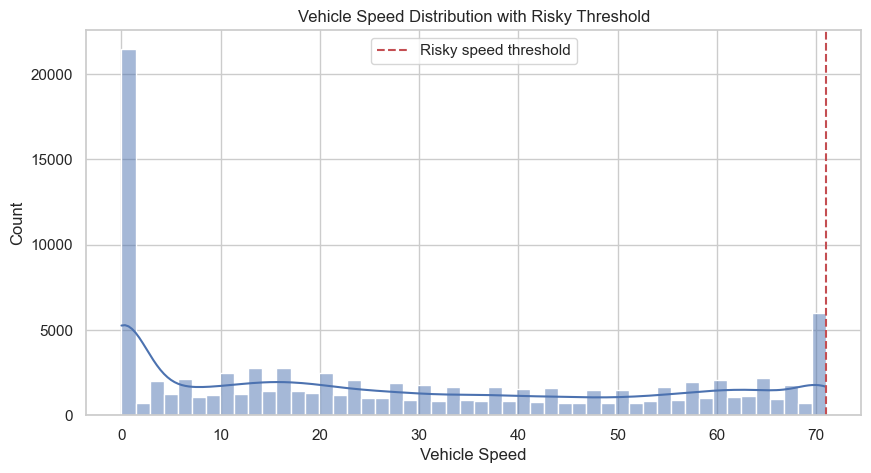

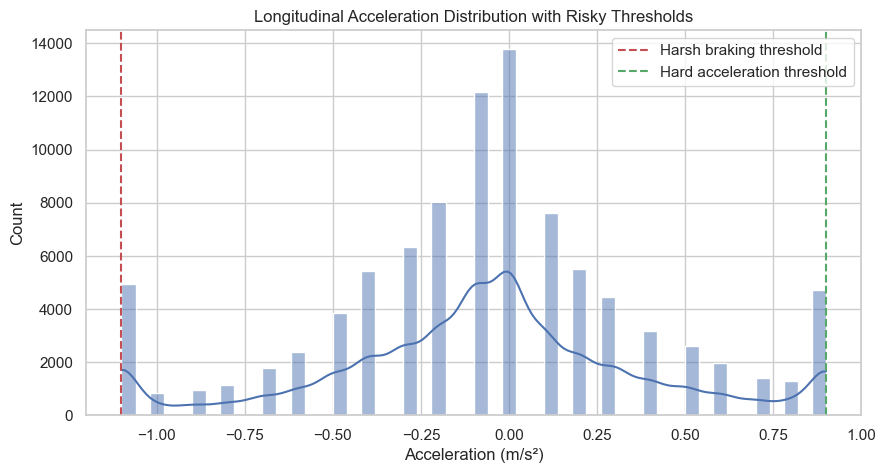

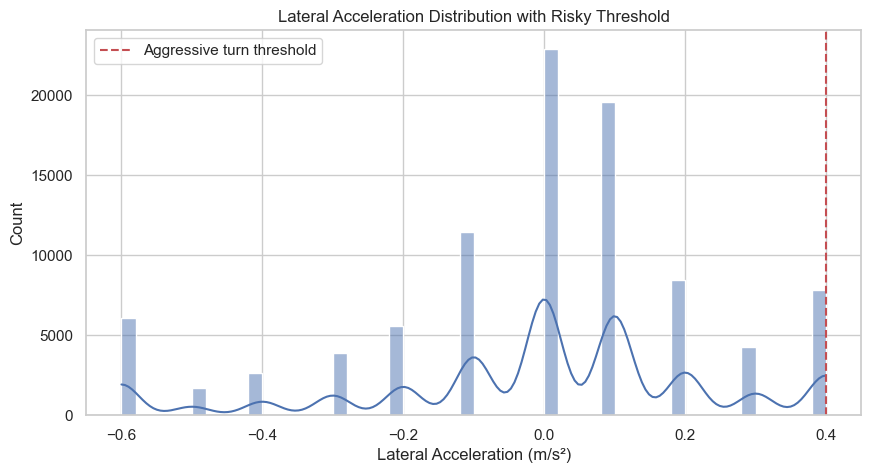

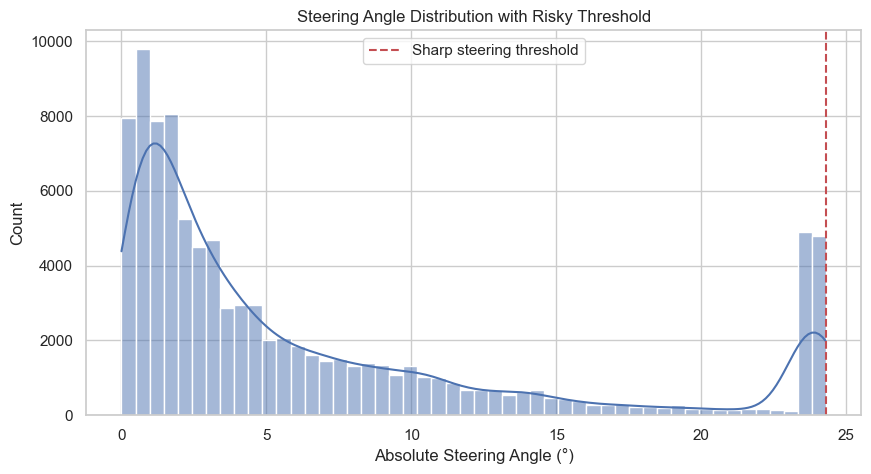

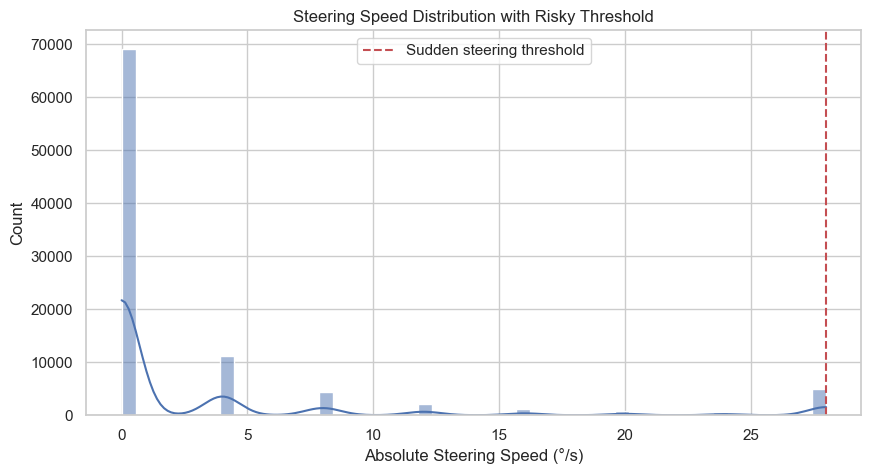

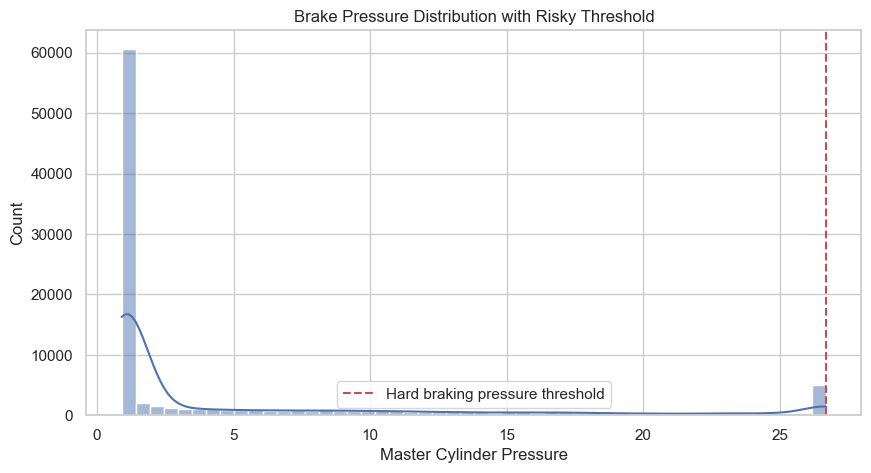

In [284]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features and their thresholds
feature_thresholds = {
    'Vehicle_speed': thresholds['Vehicle_speed'],
    'Acceleration_speed_-_Longitudinal_low': thresholds['Harsh_braking'],
    'Acceleration_speed_-_Longitudinal_high': thresholds['Hard_acceleration'],
    'Acceleration_speed_-_Lateral': thresholds['Aggressive_turn'],
    'Steering_wheel_angle': thresholds['Sharp_steering'],
    'Steering_wheel_speed': thresholds['Sudden_steering'],
    'Master_cylinder_pressure': thresholds['Hard_braking_pressure']
}

# Vehicle_speed
plt.figure(figsize=(10,5))
sns.histplot(df_features['Vehicle_speed'], bins=50, kde=True)
plt.axvline(feature_thresholds['Vehicle_speed'], color='r', linestyle='--', label='Risky speed threshold')
plt.title("Vehicle Speed Distribution with Risky Threshold")
plt.xlabel("Vehicle Speed")
plt.legend()
plt.show()

# Longitudinal acceleration
plt.figure(figsize=(10,5))
sns.histplot(df_features['Acceleration_speed_-_Longitudinal'], bins=50, kde=True)
plt.axvline(feature_thresholds['Acceleration_speed_-_Longitudinal_low'], color='r', linestyle='--', label='Harsh braking threshold')
plt.axvline(feature_thresholds['Acceleration_speed_-_Longitudinal_high'], color='g', linestyle='--', label='Hard acceleration threshold')
plt.title("Longitudinal Acceleration Distribution with Risky Thresholds")
plt.xlabel("Acceleration (m/s²)")
plt.legend()
plt.show()

# Lateral acceleration
plt.figure(figsize=(10,5))
sns.histplot(df_features['Acceleration_speed_-_Lateral'], bins=50, kde=True)
plt.axvline(feature_thresholds['Acceleration_speed_-_Lateral'], color='r', linestyle='--', label='Aggressive turn threshold')
plt.title("Lateral Acceleration Distribution with Risky Threshold")
plt.xlabel("Lateral Acceleration (m/s²)")
plt.legend()
plt.show()

# Steering angle
plt.figure(figsize=(10,5))
sns.histplot(df_features['Steering_wheel_angle'].abs(), bins=50, kde=True)
plt.axvline(feature_thresholds['Steering_wheel_angle'], color='r', linestyle='--', label='Sharp steering threshold')
plt.title("Steering Angle Distribution with Risky Threshold")
plt.xlabel("Absolute Steering Angle (°)")
plt.legend()
plt.show()

# Steering speed
plt.figure(figsize=(10,5))
sns.histplot(df_features['Steering_wheel_speed'].abs(), bins=50, kde=True)
plt.axvline(feature_thresholds['Steering_wheel_speed'], color='r', linestyle='--', label='Sudden steering threshold')
plt.title("Steering Speed Distribution with Risky Threshold")
plt.xlabel("Absolute Steering Speed (°/s)")
plt.legend()
plt.show()

# Master cylinder pressure
plt.figure(figsize=(10,5))
sns.histplot(df_features['Master_cylinder_pressure'], bins=50, kde=True)
plt.axvline(feature_thresholds['Master_cylinder_pressure'], color='r', linestyle='--', label='Hard braking pressure threshold')
plt.title("Brake Pressure Distribution with Risky Threshold")
plt.xlabel("Master Cylinder Pressure")
plt.legend()
plt.show()


In [285]:
# Create a new column 'risky' (1 = risky, 0 = normal)
df_features['risky'] = (
    (df_features['Vehicle_speed'] >= thresholds['Vehicle_speed']) |
    (df_features['Acceleration_speed_-_Longitudinal'] <= thresholds['Harsh_braking']) |
    (df_features['Acceleration_speed_-_Longitudinal'] >= thresholds['Hard_acceleration']) |
    (df_features['Acceleration_speed_-_Lateral'] >= thresholds['Aggressive_turn']) |
    (df_features['Steering_wheel_angle'].abs() >= thresholds['Sharp_steering']) |
    (df_features['Steering_wheel_speed'].abs() >= thresholds['Sudden_steering']) |
    (df_features['Master_cylinder_pressure'] >= thresholds['Hard_braking_pressure'])
).astype(int)

# Check labeled data
df_features['risky'].value_counts()
#final decesion because there r risky events


risky
0    64629
1    29751
Name: count, dtype: int64

## Normalization : 
. After labelling the data with the defined rules

In [286]:

scaler = MinMaxScaler()
df_normalized = df_cleaned.copy()
df_normalized[numeric_cols] = scaler.fit_transform(df_normalized[numeric_cols])

df_cleaned = df_normalized
print("\n✓ Normalization applied (Min-Max scaling to [0, 1])")
print(df_cleaned.shape)


✓ Normalization applied (Min-Max scaling to [0, 1])
(94380, 33)


**Analysis :**

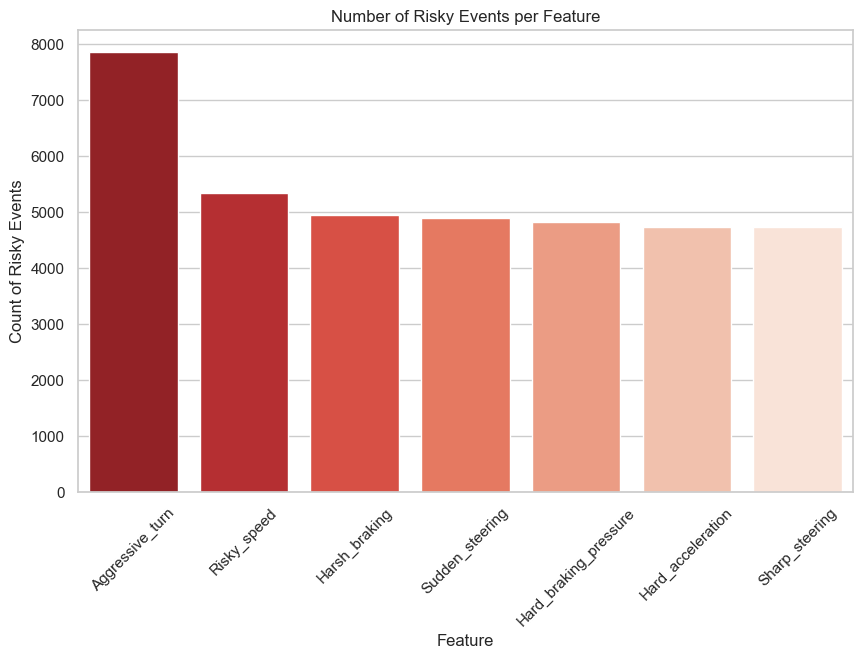

In [287]:
# Create binary columns for risky events per feature
df_features['Risky_speed'] = (df_features['Vehicle_speed'] >= thresholds['Vehicle_speed']).astype(int)
df_features['Harsh_braking'] = (df_features['Acceleration_speed_-_Longitudinal'] <= thresholds['Harsh_braking']).astype(int)
df_features['Hard_acceleration'] = (df_features['Acceleration_speed_-_Longitudinal'] >= thresholds['Hard_acceleration']).astype(int)
df_features['Aggressive_turn'] = (df_features['Acceleration_speed_-_Lateral'] >= thresholds['Aggressive_turn']).astype(int)
df_features['Sharp_steering'] = (df_features['Steering_wheel_angle'].abs() >= thresholds['Sharp_steering']).astype(int)
df_features['Sudden_steering'] = (df_features['Steering_wheel_speed'].abs() >= thresholds['Sudden_steering']).astype(int)
df_features['Hard_braking_pressure'] = (df_features['Master_cylinder_pressure'] >= thresholds['Hard_braking_pressure']).astype(int)

# Sum risky events per feature
risky_summary = df_features[['Risky_speed','Harsh_braking','Hard_acceleration','Aggressive_turn',
                             'Sharp_steering','Sudden_steering','Hard_braking_pressure']].sum().sort_values(ascending=False)
# Convert Series to DataFrame
risky_df = risky_summary.reset_index()
risky_df.columns = ['Feature','Count']

# Plot with hue
plt.figure(figsize=(10,6))
sns.barplot(x='Feature', y='Count', data=risky_df, hue='Feature', palette="Reds_r", dodge=False, legend=False)
plt.title("Number of Risky Events per Feature")
plt.ylabel("Count of Risky Events")
plt.xticks(rotation=45)
plt.show()


In [288]:
X = df_features[
    [
        'Vehicle_speed',
        'Acceleration_speed_-_Longitudinal',
        'Acceleration_speed_-_Lateral',
        'Steering_wheel_angle',
        'Steering_wheel_speed',
        'Master_cylinder_pressure'
    ]
]

y = df_features['risky']

In [289]:
#add a colom to cleaned data with risky label and save it for future use
df_cleaned_with_label = df_cleaned.copy()
df_cleaned_with_label['risky'] = y
df_cleaned_with_label.to_csv(TRANSFORMED_DATA_PATH, index=False)
print(f"\n✓ Cleaned data with risky label saved to: {TRANSFORMED_DATA_PATH}")
print(f"  File size: {TRANSFORMED_DATA_PATH.stat().st_size /
1024 / 1024:.2f} MB")





✓ Cleaned data with risky label saved to: C:\Users\idris\Modules\3rd\S1\DM\CDTA\CDTA-AI-Model-Development-For-Driving-Assessment\data\transformed\Driving_Data_With_Risky_Label.csv
  File size: 37.14 MB


## Dimensionality Reduction (PCA)
We apply PCA on the numeric features (excluding `Class` , `Time(s)` and `risky` if present) to reduce dimensionality while preserving most variance.

* we used PCA inorder to reduce the complexity of the data and also use some compatible models with it 

Components for 95% variance: 19
Components for 99% variance: 24
Using n_components=19
PCA components retained: 19
Total variance retained: 0.9565


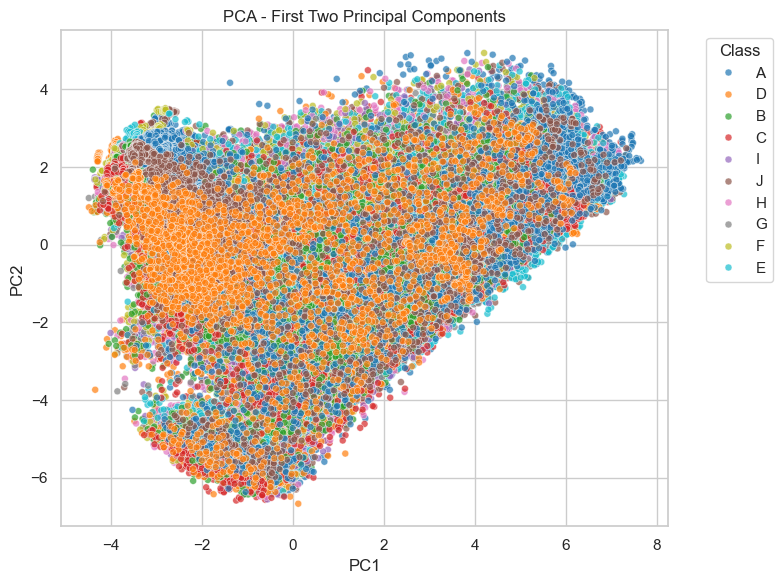

In [290]:
# Prepare data for PCA
df = pd.read_csv(TRANSFORMED_DATA_PATH)


pca_df = df.copy()

y = None
if 'Class' in pca_df.columns:
    y = pca_df['Class']

X = pca_df.select_dtypes(include='number')
X = X.drop(columns=['Class', 'Time(s)' , 'risky'], errors='ignore')

# Handle missing values (median imputation)
X = X.fillna(X.median(numeric_only=True))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Variance rule: smallest n to explain ~95–99% variance
import numpy as np

pca_full = PCA()
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)
n_99 = int(np.argmax(cum_var >= 0.99) + 1)
n_components_variance = n_95

print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")
print(f"Using n_components={n_components_variance}")

pca = PCA(n_components=n_components_variance)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print(f"PCA components retained: {pca.n_components_}")
print(f"Total variance retained: {explained_var.sum():.4f}")

# Build PCA dataframe
pc_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
pca_result_df = pd.DataFrame(X_pca, columns=pc_columns)

# Visualize first two components if available
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    if y is not None:
        sns.scatterplot(x=pca_result_df['PC1'], y=pca_result_df['PC2'], hue=y, palette='tab10', s=25, alpha=0.7)
        plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        sns.scatterplot(x=pca_result_df['PC1'], y=pca_result_df['PC2'], s=25, alpha=0.7)
    plt.title('PCA - First Two Principal Components')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.tight_layout()
    plt.show()

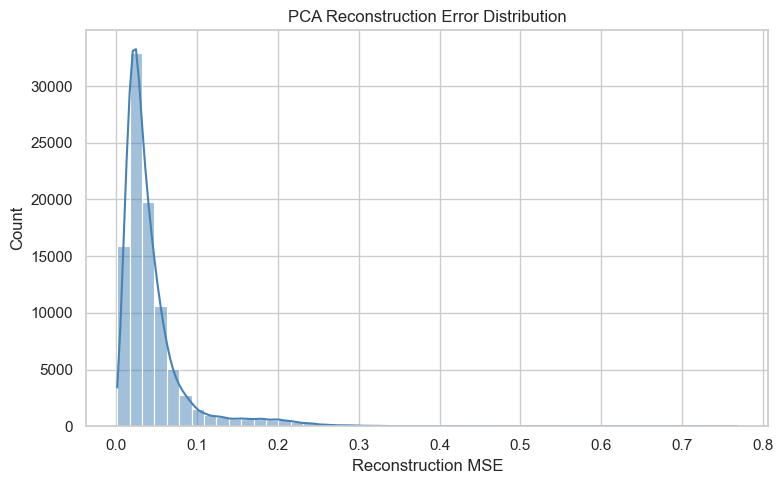

Reconstruction error: mean=0.043534, std=0.042777, max=0.768327


In [292]:
# Reconstruction error distribution (PCA)
X_reconstructed = pca.inverse_transform(X_pca)
recon_error = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(recon_error, bins=50, kde=True, color='steelblue')
plt.title('PCA Reconstruction Error Distribution')
plt.xlabel('Reconstruction MSE')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Reconstruction error: mean={recon_error.mean():.6f}, std={recon_error.std():.6f}, max={recon_error.max():.6f}")

In [293]:
# Validation rule: try 5, 10, 15, 20 components and compare anomaly rates
df = pd.read_csv(TRANSFORMED_DATA_PATH)

df.drop(columns=['Class', 'Time(s)', 'risky'], inplace=True, errors='ignore') 

pca_df = df.copy()

X = pca_df.select_dtypes(include='number')
X = X.drop(columns=['Class', 'Time(s)' , 'risky'], errors='ignore')

# Handle missing values (median imputation)
X = X.fillna(X.median(numeric_only=True))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

component_grid = [5, 10, 15, 20]
validation_results = []

for n_components in component_grid:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
    iso_labels = iso.fit_predict(X_pca)
    iso_anomaly_rate = (iso_labels == -1).mean()

    ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.02)
    svm_labels = ocsvm.fit_predict(X_pca)
    svm_anomaly_rate = (svm_labels == -1).mean()

    validation_results.append({
        'n_components': n_components,
        'iso_anomaly_pct': iso_anomaly_rate * 100,
        'svm_anomaly_pct': svm_anomaly_rate * 100
    })

validation_df = pd.DataFrame(validation_results)
print(validation_df)

   n_components  iso_anomaly_pct  svm_anomaly_pct
0             5         2.000424         2.001483
1            10         2.000424         2.002543
2            15         2.000424         2.007841
3            20         2.000424         2.002543


# Modeling part :

### Approach Selection (Unsupervised Learning)

Based on the data provided, the most suitable machine learning setup is **unsupervised learning**, since no reliable ground-truth target labels are available. In this context, **clustering** is an appropriate choice because it helps uncover the natural structure of the data by grouping similar observations together.

Although clustering itself does **not require predefined labels**, we still introduce a **labeling step after clustering**. These cluster assignments act as *pseudo-labels* and are useful for two reasons:

- **Interpretability:** they allow us to describe and compare the discovered groups.
- **Anomaly Detection:** once clusters are formed, we can flag anomalies as points that are *far from their assigned cluster center*, fall into *very small clusters*, or show *low similarity* to all clusters.

In short, we use clustering to learn patterns from the data, then leverage the resulting cluster IDs as labels to support downstream **anomaly detection** and analysis.


### Modeling Structure (Simple)

We build an **supervised** pipeline because the data has **ground-truth labels**.  
So we  use those labels for **classification** and **anomaly detection**.

---

#### ✅ Steps

1) **Preprocessing ( 2 approaches)**
- **PCA** (dimensionality reduction)
- **FFS (7 features)**
- **FFS (12 features)**

2) **Classification**
- Train a classifier using the pseudo-labels (cluster IDs).
- Goal: quickly assign a cluster to **new data** without rerunning clustering.

3) **Anomaly Detection**
- Detect anomalies as points that:
  - are far from their cluster center, or
  - belong to very small / rare clusters.

---

### Graph (Pipeline)

```text
                ┌───────────────┐
                │     Data      │
                └───────┬───────┘
                        │
        ┌───────────────┼────────────────┐
        │               │                │
   ┌────▼────┐     ┌────▼────┐      ┌────▼─────┐
   │   PCA   │     │ FFS (7) │      │ FFS (12) │
   └────┬────┘     └────┬────┘      └────┬─────┘─┘
        │                │                │
   ┌────▼────┐      ┌────▼────┐      ┌────▼────   ┐
   │Classifier│      │Classifier│      │Classifier│
   │ (PCA)    │      │ (FFS 7)  │      │ (FFS 12) │
   └────┬────┘      └────┬────┘      └────┬────   ┘
        │                │                │
   ┌────▼────────────────▼────────────────▼───── ┐
   │              Anomaly Detection              │
   └─────────────────────────────────────────────┘


# PCA Approuch : 

# FFS (7) :


In [ ]:
X = df_features[
    [
        'Vehicle_speed',
        'Acceleration_speed_-_Longitudinal',
        'Acceleration_speed_-_Lateral',
        'Steering_wheel_angle',
        'Steering_wheel_speed',
        'Master_cylinder_pressure'
    ]
]

y = df_features['risky']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


### Classification 

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


### Anomally detection :

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance")
plt.show()

**Drivers Score**

**🔹 OVERVIEW**

We want to compute a GOOD DRIVER SCORE (0–100) per driver
where:

1.Each driver has many driving events

2.Risk comes from Random Forest probabilities

**Wheighted Method :**

Overall mathematical idea :


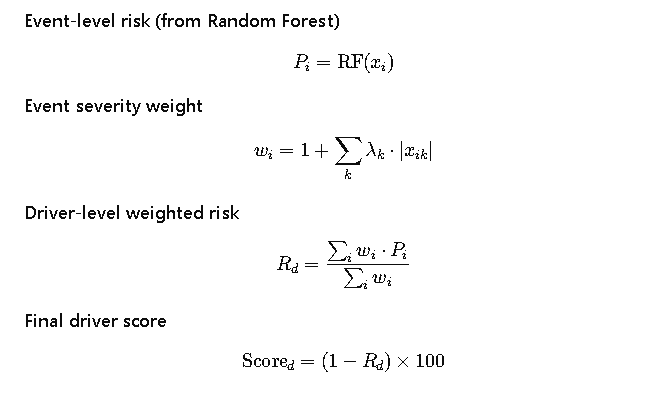


In [ ]:
df_features["event_risk_prob"] = rf_model.predict_proba(X)[:, 1]
severity_features = [
    "Vehicle_speed",
    "Acceleration_speed_-_Longitudinal",
    "Acceleration_speed_-_Lateral",
    "Steering_wheel_angle",
    "Steering_wheel_speed",
    "Master_cylinder_pressure"
]

#Normalize severity features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_features[severity_features] = scaler.fit_transform(
    df_features[severity_features]
)




In [ ]:
X = df_features[selected_features].copy()

print(X.shape)
print(X.columns)

rf_model.fit(X, y)
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

importance_df["weight"] = (
    importance_df["importance"] /
    importance_df["importance"].sum()
)

importance_df




**Note :**      

Feature importance values are extracted from the trained Random Forest model. To ensure alignment, the importance scores are mapped to the exact feature set used during model training.

In [ ]:
import numpy as np
df_features["event_weight"] = 1.0

for feature in severity_features:
    df_features["event_weight"] += (
        importance_df
        .set_index("feature")
        .loc[feature, "weight"]
        * np.abs(df_features[feature])
    )


In [ ]:
#Re-attach driver column
df_features["Class"] = df.loc[df_features.index, "Class"]
df_features["Class"].value_counts()




In [ ]:
driver_scores = (
    df_features
    .groupby("Class")
    .apply(lambda x: np.average(
        x["event_risk_prob"],
        weights=x["event_weight"]
    ))
    .reset_index(name="driver_weighted_risk")
)

driver_scores["driver_score"] = (
    (1 - driver_scores["driver_weighted_risk"]) * 100
).round(1)

driver_scores


In [ ]:

plt.figure(figsize=(8,5))
plt.hist(driver_scores["driver_score"], bins=30)
plt.xlabel("Driver Score (0 = risky, 100 = safe)")
plt.ylabel("Number of Drivers")
plt.title("Weighted Driver Safety Score Distribution")
plt.show()


Note :       

We worked on a weighted driver scoring method that accounts for both the likelihood and severity of risky driving events. Event-level risk probabilities are predicted using a Random Forest classifier trained on behavior-related features. To capture severity, continuous driving dynamics such as speed, acceleration, steering, and braking pressure are normalized and combined using feature importance derived from the trained model. Driver-level risk is computed as a weighted average of event probabilities, and finally transformed into a safety score ranging from 0 to 100.

# FFS (12)

## Anomaly Detection (Isolation Forest)
We use Isolation Forest on standardized numeric features (excluding `Class` , `Time(s)` and `risky`) to flag potential anomalies.

Test anomalies detected: 397 (2.10%)
Accuracy: 0.698
Precision: 0.816 | Recall: 0.054 | F1: 0.102
              precision    recall  f1-score   support

      Normal       0.70      0.99      0.82     12926
       Risky       0.82      0.05      0.10      5950

    accuracy                           0.70     18876
   macro avg       0.76      0.52      0.46     18876
weighted avg       0.73      0.70      0.59     18876



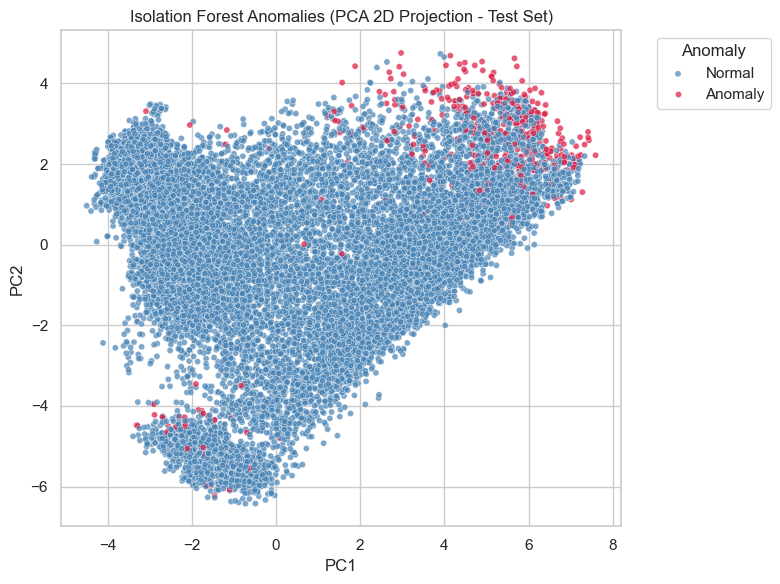

In [294]:
# Prepare data for Isolation Forest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
df = pd.read_csv(TRANSFORMED_DATA_PATH)
iso_df = df.copy()

y_iso = None
if 'Class' in iso_df.columns:
    y_iso = iso_df['Class']

X_iso = iso_df.select_dtypes(include='number')
X_iso = X_iso.drop(columns=['Class', 'Time(s)', 'risky'], errors='ignore')

# Handle missing values (median imputation)
X_iso = X_iso.fillna(X_iso.median(numeric_only=True))

y_risky = iso_df['risky'] if 'risky' in iso_df.columns else None

# Train/test split (80/20)
X_iso_train, X_iso_test, y_train, y_test = train_test_split(
    X_iso,
    y_risky,
    test_size=0.2,
    random_state=42,
    stratify=y_risky if y_risky is not None else None
)

# Standardize features (fit on train, apply to test)
scaler_iso = StandardScaler()
X_iso_train_scaled = scaler_iso.fit_transform(X_iso_train)
X_iso_test_scaled = scaler_iso.transform(X_iso_test)

# Isolation Forest (fit on train, evaluate on test)
iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
iso.fit(X_iso_train_scaled)
iso_labels_test = iso.predict(X_iso_test_scaled)

# -1 = anomaly, 1 = normal
iso_test = iso_df.loc[X_iso_test.index].copy()
iso_test['is_anomaly'] = iso_labels_test
anomaly_count = (iso_test['is_anomaly'] == -1).sum()
print(f"Test anomalies detected: {anomaly_count} ({anomaly_count / len(iso_test) * 100:.2f}%)")

# Evaluate against risky label if available
if y_test is not None:
    y_true = (y_test == 1).astype(int)
    y_pred = (iso_labels_test == -1).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Risky'], zero_division=0))

# Visualize anomalies using first two PCA components for 2D view (test set)
pca_vis = PCA(n_components=2)
iso_2d = pca_vis.fit_transform(X_iso_test_scaled)
iso_plot = pd.DataFrame(iso_2d, columns=['PC1', 'PC2'], index=X_iso_test.index)
iso_plot['is_anomaly'] = iso_test['is_anomaly'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iso_plot,
    x='PC1',
    y='PC2',
    hue='is_anomaly',
    palette={1: 'steelblue', -1: 'crimson'},
    alpha=0.7,
    s=20
)
plt.title('Isolation Forest Anomalies (PCA 2D Projection - Test Set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## One-Class SVM


CROSS-VALIDATION RESULTS (5-Fold on Training Set)
Fold 1: Acc=0.6939, Prec=0.7184, Rec=0.0477, F1=0.0894
Fold 2: Acc=0.6932, Prec=0.6966, Rec=0.0473, F1=0.0885
Fold 3: Acc=0.6945, Prec=0.7276, Rec=0.0494, F1=0.0925
Fold 4: Acc=0.6923, Prec=0.6825, Rec=0.0452, F1=0.0847
Fold 5: Acc=0.6931, Prec=0.7006, Rec=0.0462, F1=0.0867

Metric       Mean       Std       
--------------------------------
Accuracy     0.6934   ±0.0007
Precision    0.7051   ±0.0160
Recall       0.0471   ±0.0014
F1-score     0.0884   ±0.0026

FINAL MODEL EVALUATION (Hold-out Test Set)
One-Class SVM test anomalies: 375 (1.99%)
Accuracy: 0.692
Precision: 0.688 | Recall: 0.043 | F1: 0.082
              precision    recall  f1-score   support

      Normal       0.69      0.99      0.82     12926
       Risky       0.69      0.04      0.08      5950

    accuracy                           0.69     18876
   macro avg       0.69      0.52      0.45     18876
weighted avg       0.69      0.69      0.58     18876



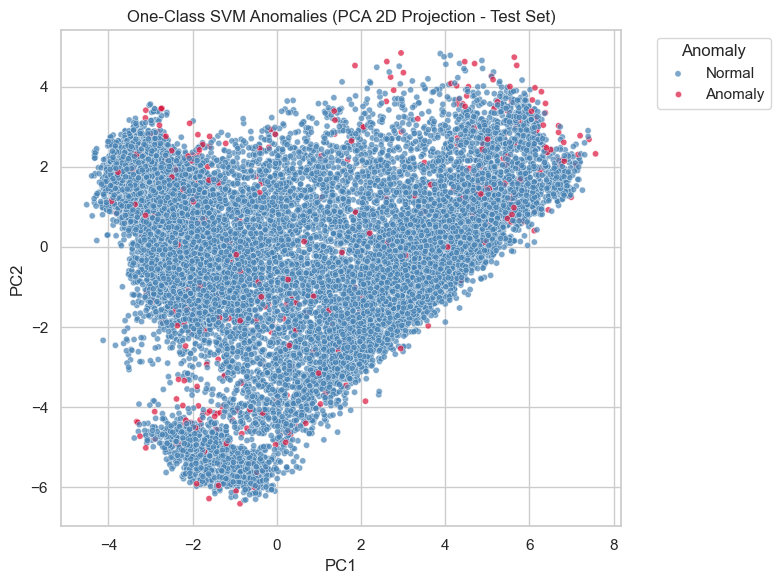

In [295]:
# One-Class SVM (Anomaly Detection)
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

svm_df = df.copy()

X_svm = svm_df.select_dtypes(include='number')
X_svm = X_svm.drop(columns=['Class', 'Time(s)'], errors='ignore')
X_svm = X_svm.fillna(X_svm.median(numeric_only=True))

y_risky = svm_df['risky'] if 'risky' in svm_df.columns else None

# Train/test split (80/20)
X_svm_train, X_svm_test, y_train, y_test = train_test_split(
    X_svm,
    y_risky,
    test_size=0.2,
    random_state=42,
    stratify=y_risky if y_risky is not None else None
)

# Standardize features (fit on train, apply to test)
scaler_svm = StandardScaler()
X_svm_train_scaled = scaler_svm.fit_transform(X_svm_train)
X_svm_test_scaled = scaler_svm.transform(X_svm_test)

# Cross-validation on training set (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

print("="*80)
print("CROSS-VALIDATION RESULTS (5-Fold on Training Set)")
print("="*80)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_svm_train_scaled, y_train), start=1):
    X_tr, X_val = X_svm_train_scaled[train_idx], X_svm_train_scaled[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.02)
    ocsvm.fit(X_tr)
    val_preds = ocsvm.predict(X_val)

    y_true = (y_val == 1).astype(int)
    y_pred = (val_preds == -1).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    cv_metrics['accuracy'].append(acc)
    cv_metrics['precision'].append(precision)
    cv_metrics['recall'].append(recall)
    cv_metrics['f1'].append(f1)

    print(f"Fold {fold}: Acc={acc:.4f}, Prec={precision:.4f}, Rec={recall:.4f}, F1={f1:.4f}")

print(f"\n{'Metric':<12} {'Mean':<10} {'Std':<10}")
print("-"*32)
print(f"{'Accuracy':<12} {np.mean(cv_metrics['accuracy']):.4f}   ±{np.std(cv_metrics['accuracy']):.4f}")
print(f"{'Precision':<12} {np.mean(cv_metrics['precision']):.4f}   ±{np.std(cv_metrics['precision']):.4f}")
print(f"{'Recall':<12} {np.mean(cv_metrics['recall']):.4f}   ±{np.std(cv_metrics['recall']):.4f}")
print(f"{'F1-score':<12} {np.mean(cv_metrics['f1']):.4f}   ±{np.std(cv_metrics['f1']):.4f}")

# Train on full training set and test
print("\n" + "="*80)
print("FINAL MODEL EVALUATION (Hold-out Test Set)")
print("="*80)

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.02)
ocsvm.fit(X_svm_train_scaled)
svm_labels_test = ocsvm.predict(X_svm_test_scaled)

# -1 = anomaly, 1 = normal
svm_test = svm_df.loc[X_svm_test.index].copy()
svm_test['is_anomaly_svm'] = svm_labels_test
svm_anomaly_count = (svm_test['is_anomaly_svm'] == -1).sum()
print(f"One-Class SVM test anomalies: {svm_anomaly_count} ({svm_anomaly_count / len(svm_test) * 100:.2f}%)")

# Evaluate against risky label if available
if y_test is not None:
    y_true = (y_test == 1).astype(int)
    y_pred = (svm_labels_test == -1).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Risky'], zero_division=0))

# Visualize anomalies using first two PCA components for 2D view (test set)
pca_vis_svm = PCA(n_components=2)
svm_2d = pca_vis_svm.fit_transform(X_svm_test_scaled)
svm_plot = pd.DataFrame(svm_2d, columns=['PC1', 'PC2'], index=X_svm_test.index)
svm_plot['is_anomaly'] = svm_test['is_anomaly_svm'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=svm_plot,
    x='PC1',
    y='PC2',
    hue='is_anomaly',
    palette={1: 'steelblue', -1: 'crimson'},
    alpha=0.7,
    s=20
)
plt.title('One-Class SVM Anomalies (PCA 2D Projection - Test Set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

CROSS-VALIDATION RESULTS (5-Fold on Training Set)
Accuracy per fold:  [1.         1.         1.         1.         0.99993377]
Precision per fold: [1. 1. 1. 1. 1.]
Recall per fold:    [1.         1.         1.         1.         0.99978992]
F1-score per fold:  [1.         1.         1.         1.         0.99989495]

Metric       Mean       Std       
--------------------------------
Accuracy     1.0000   ±0.0000
Precision    1.0000   ±0.0000
Recall       1.0000   ±0.0001
F1-score     1.0000   ±0.0000

FINAL MODEL EVALUATION (Hold-out Test Set)
Test Accuracy:  1.0000
Test Precision: 1.0000
Test Recall:    1.0000
Test F1-score:  1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     12926
       Risky       1.00      1.00      1.00      5950

    accuracy                           1.00     18876
   macro avg       1.00      1.00      1.00     18876
weighted avg       1.00      1.00      1.00     18876

Top 10 feature importances:


Acceleration_speed_-_Longitudinal    0.190855
Acceleration_speed_-_Lateral         0.186773
Master_cylinder_pressure             0.146864
Vehicle_speed                        0.102780
Steering_wheel_speed                 0.097218
Steering_wheel_angle                 0.090363
Engine_Idel_Target_Speed             0.035297
Current_Gear                         0.031427
Torque_converter_speed               0.016881
Engine_speed                         0.016356
dtype: float64

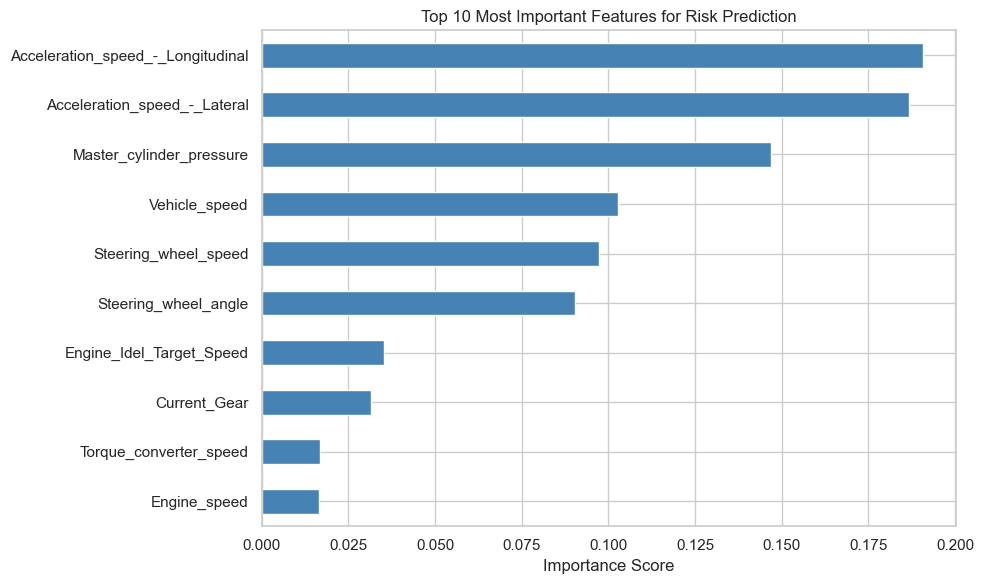

In [296]:
# Random Forest (Supervised) using risky label
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

df = pd.read_csv(TRANSFORMED_DATA_PATH)
rf_df = df.copy()

X_rf = rf_df.select_dtypes(include='number')
X_rf = X_rf.drop(columns=['Class', 'Time(s)', 'risky'], errors='ignore')
X_rf = X_rf.fillna(X_rf.median(numeric_only=True))

y_rf = rf_df['risky'].astype(int)

# Train/test split (80/20)
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf
)

# Initialize model
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

# Cross-validation on training set (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    rf,
    X_rf_train,
    y_rf_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=False
)

print("="*80)
print("CROSS-VALIDATION RESULTS (5-Fold on Training Set)")
print("="*80)
print(f"Accuracy per fold:  {cv_scores['test_accuracy']}")
print(f"Precision per fold: {cv_scores['test_precision']}")
print(f"Recall per fold:    {cv_scores['test_recall']}")
print(f"F1-score per fold:  {cv_scores['test_f1']}")

print(f"\n{'Metric':<12} {'Mean':<10} {'Std':<10}")
print("-"*32)
print(f"{'Accuracy':<12} {cv_scores['test_accuracy'].mean():.4f}   ±{cv_scores['test_accuracy'].std():.4f}")
print(f"{'Precision':<12} {cv_scores['test_precision'].mean():.4f}   ±{cv_scores['test_precision'].std():.4f}")
print(f"{'Recall':<12} {cv_scores['test_recall'].mean():.4f}   ±{cv_scores['test_recall'].std():.4f}")
print(f"{'F1-score':<12} {cv_scores['test_f1'].mean():.4f}   ±{cv_scores['test_f1'].std():.4f}")

# Train on full training set and test
print("\n" + "="*80)
print("FINAL MODEL EVALUATION (Hold-out Test Set)")
print("="*80)
rf.fit(X_rf_train, y_rf_train)
y_rf_pred = rf.predict(X_rf_test)

acc = accuracy_score(y_rf_test, y_rf_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_rf_test, y_rf_pred, average='binary', zero_division=0)
print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test F1-score:  {f1:.4f}")
print(classification_report(y_rf_test, y_rf_pred, target_names=['Normal', 'Risky'], zero_division=0))

# Feature importance (top 10)
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
print("Top 10 feature importances:")
display(importances.head(10))

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features for Risk Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [297]:
df = pd.read_csv("../data/raw/Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J).csv")

# Show first rows
df.head()


,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,Fuel_Pressure,Long_Term_Fuel_Trim_Bank1,Engine_speed,Engine_torque_after_correction,Torque_of_friction,Flywheel_torque_(after_torque_interventions),Current_spark_timing,Engine_coolant_temperature,Engine_Idel_Target_Speed,Engine_torque,Calculated_LOAD_value,Minimum_indicated_engine_torque,Maximum_indicated_engine_torque,Flywheel_torque,Torque_scaling_factor(standardization),...,Target_engine_speed_used_in_lock-up_module,Glow_plug_control_request,Activation_of_Air_compressor,Torque_converter_speed,Current_Gear,Engine_coolant_temperature.1,Wheel_velocity_front_left-hand,Wheel_velocity_rear_right-hand,Wheel_velocity_front_right-hand,Wheel_velocity_rear_left-hand,Torque_converter_turbine_speed_-_Unfiltered,Clutch_operation_acknowledge,Converter_clutch,Gear_Selection,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,5.2,0.0,33,0,13.3,3,0,0,0,-0.8,929,5.5,9.0,-5.9,-8.6,95,650,5.5,23.9,2.0,58.2,-5.9,230,...,3040,0,0,939.3,0,87,0.0,0.0,0.0,0.0,935.5,1,0,0,0,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,0,13.7,3,0,0,0,-0.8,726,7.0,7.8,1.7,-11.3,95,670,7.0,30.6,2.0,53.9,1.8,230,...,3040,0,0,710.0,0,87,0.0,0.0,0.0,0.0,709.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,0.0,41,0,13.7,3,0,0,0,-0.8,685,7.0,7.4,-3.0,-12.8,95,670,7.0,31.8,2.0,53.1,-2.8,230,...,3040,0,0,663.3,0,87,0.0,0.0,0.0,0.0,663.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,0.0,38,0,13.3,3,0,0,0,-0.8,675,7.0,6.6,-1.3,-9.8,95,670,7.0,29.0,2.0,53.1,-1.2,230,...,3040,0,0,652.5,0,87,0.0,0.0,0.0,0.0,653.0,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,0.0,40,0,13.7,3,0,0,0,-0.8,716,8.2,11.3,-15.6,-7.9,95,670,8.2,30.2,2.0,53.5,-15.9,230,...,3040,0,1,692.5,0,87,0.0,0.0,0.0,0.0,693.8,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1


In [298]:
# Number of rows and columns
print("Dataset shape:", df.shape)

# List all column names
print("\nColumns:")
print(df.columns)

# Detailed info: data types & missing values
df.info()

Dataset shape: (94380, 54)

Columns:
Index(['Fuel_consumption', 'Accelerator_Pedal_value',
       'Throttle_position_signal', 'Short_Term_Fuel_Trim_Bank1',
       'Intake_air_pressure', 'Filtered_Accelerator_Pedal_value',
       'Absolute_throttle_position', 'Engine_soacking_time',
       'Inhibition_of_engine_fuel_cut_off', 'Engine_in_fuel_cut_off',
       'Fuel_Pressure', 'Long_Term_Fuel_Trim_Bank1', 'Engine_speed',
       'Engine_torque_after_correction', 'Torque_of_friction',
       'Flywheel_torque_(after_torque_interventions)', 'Current_spark_timing',
       'Engine_coolant_temperature', 'Engine_Idel_Target_Speed',
       'Engine_torque', 'Calculated_LOAD_value',
       'Minimum_indicated_engine_torque', 'Maximum_indicated_engine_torque',
       'Flywheel_torque', 'Torque_scaling_factor(standardization)',
       'Standard_Torque_Ratio', 'Requested_spark_retard_angle_from_TCU',
       'TCU_requests_engine_torque_limit_(ETL)',
       'TCU_requested_engine_RPM_increase',
       'Tar

In [299]:
df[df["Vehicle_speed"] >= 0].shape

(94380, 54)

In [300]:
# selected features based on driving behavior logic
selected_features = [
    "Vehicle_speed",
    "Acceleration_speed_-_Longitudinal",
    "Acceleration_speed_-_Lateral",
    "Steering_wheel_angle",
    "Steering_wheel_speed",
    "Master_cylinder_pressure",
    "Indication_of_brake_switch_ON/OFF"
]


In [301]:
missing = [col for col in selected_features if col not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All selected features are present.")

All selected features are present.


In [302]:
df_features = df[selected_features].copy()

# Preview the new dataset
df_features.head()

,Vehicle_speed,Acceleration_speed_-_Longitudinal,Acceleration_speed_-_Lateral,Steering_wheel_angle,Steering_wheel_speed,Master_cylinder_pressure,Indication_of_brake_switch_ON/OFF
0,0,-8.5,-8.8,-3.4,0,325.5,1
1,0,0.1,-0.2,-3.6,0,0.9,1
2,0,0.1,-0.2,-3.6,0,0.9,1
3,0,0.1,-0.2,-3.6,0,0.9,1
4,0,0.1,-0.2,-3.5,0,0.9,1


In [303]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94380 entries, 0 to 94379
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Vehicle_speed                      94380 non-null  int64  
 1   Acceleration_speed_-_Longitudinal  94380 non-null  float64
 2   Acceleration_speed_-_Lateral       94380 non-null  float64
 3   Steering_wheel_angle               94380 non-null  float64
 4   Steering_wheel_speed               94380 non-null  int64  
 5   Master_cylinder_pressure           94380 non-null  float64
 6   Indication_of_brake_switch_ON/OFF  94380 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 5.0 MB


In [304]:
df_features.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,Vehicle_speed,Acceleration_speed_-_Longitudinal,Acceleration_speed_-_Lateral,Steering_wheel_angle,Steering_wheel_speed,Master_cylinder_pressure,Indication_of_brake_switch_ON/OFF
count,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000
mean,28.518881,-0.076198,-0.007616,0.773593,6.362407,5.686715,1.356294
std,25.309664,0.593006,0.417956,60.815388,26.467043,9.904240,0.479017
min,0.000000,-10.200000,-10.200000,-516.800000,0.000000,0.000000,0.000000
25%,4.000000,-0.300000,-0.100000,-2.600000,0.000000,1.000000,1.000000
50%,23.000000,-0.100000,0.000000,0.800000,0.000000,1.100000,1.000000
75%,51.000000,0.200000,0.100000,4.000000,4.000000,5.900000,2.000000
90%,65.000000,0.500000,0.300000,11.610000,12.000000,18.300000,2.000000
95%,71.000000,0.900000,0.400000,24.300000,28.000000,26.700000,2.000000
99%,83.000000,1.400000,1.100000,219.642000,136.000000,39.800000,2.000000


In [305]:
thresholds = {}

# Vehicle speed: risky if in top 5%
thresholds['Vehicle_speed'] = df_features['Vehicle_speed'].quantile(0.95)

# Longitudinal acceleration: harsh braking if very negative, hard acceleration if very positive
thresholds['Harsh_braking'] = df_features['Acceleration_speed_-_Longitudinal'].quantile(0.05)
thresholds['Hard_acceleration'] = df_features['Acceleration_speed_-_Longitudinal'].quantile(0.95)

# Lateral acceleration: risky if top 5%
thresholds['Aggressive_turn'] = df_features['Acceleration_speed_-_Lateral'].quantile(0.95)

# Steering wheel angle: risky if sharp turns (top 5% by absolute value)
thresholds['Sharp_steering'] = df_features['Steering_wheel_angle'].abs().quantile(0.95)

# Steering wheel speed: risky if sudden steering changes
thresholds['Sudden_steering'] = df_features['Steering_wheel_speed'].abs().quantile(0.95)

# Master cylinder pressure: risky if high braking force
thresholds['Hard_braking_pressure'] = df_features['Master_cylinder_pressure'].quantile(0.95)

# Brake switch: risky if ON during high braking (we can consider pressure threshold)
thresholds['Brake_switch_on'] = df_features['Master_cylinder_pressure'].quantile(0.95)

thresholds

{'Vehicle_speed': np.float64(71.0),
 'Harsh_braking': np.float64(-1.1),
 'Hard_acceleration': np.float64(0.9),
 'Aggressive_turn': np.float64(0.4),
 'Sharp_steering': np.float64(70.9050000000003),
 'Sudden_steering': np.float64(28.0),
 'Hard_braking_pressure': np.float64(26.7),
 'Brake_switch_on': np.float64(26.7)}

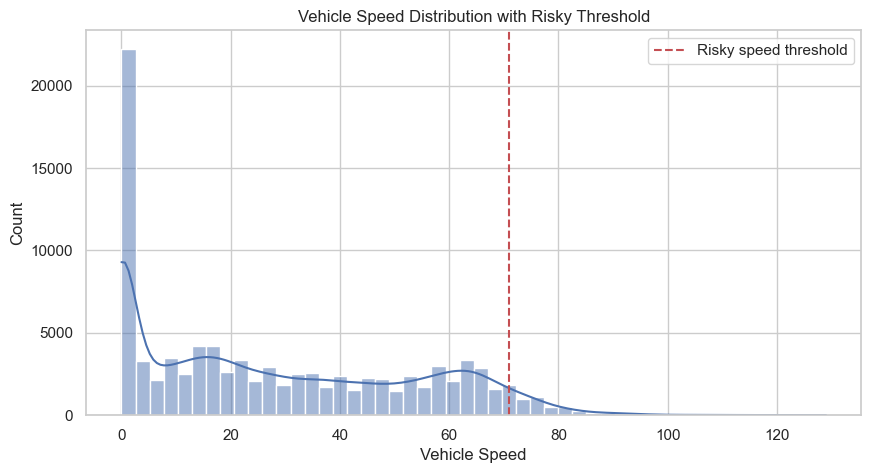

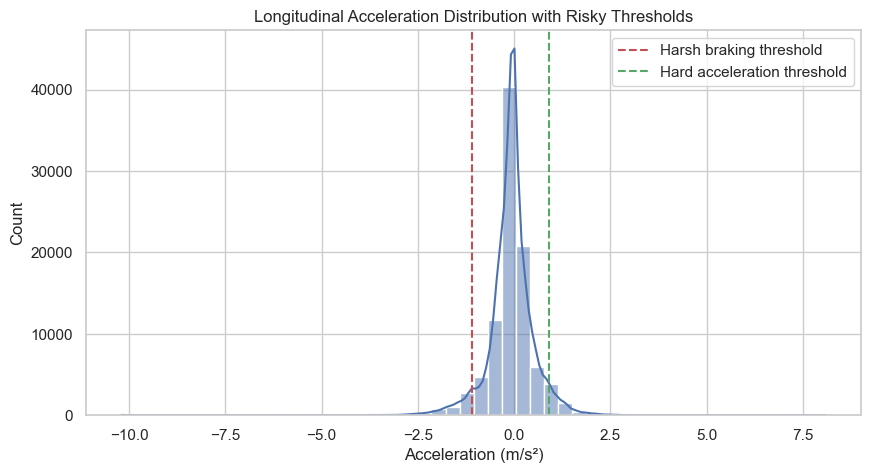

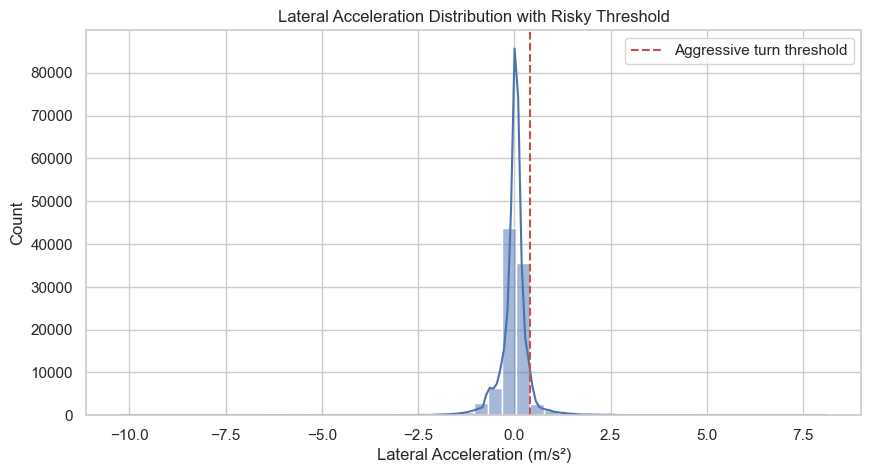

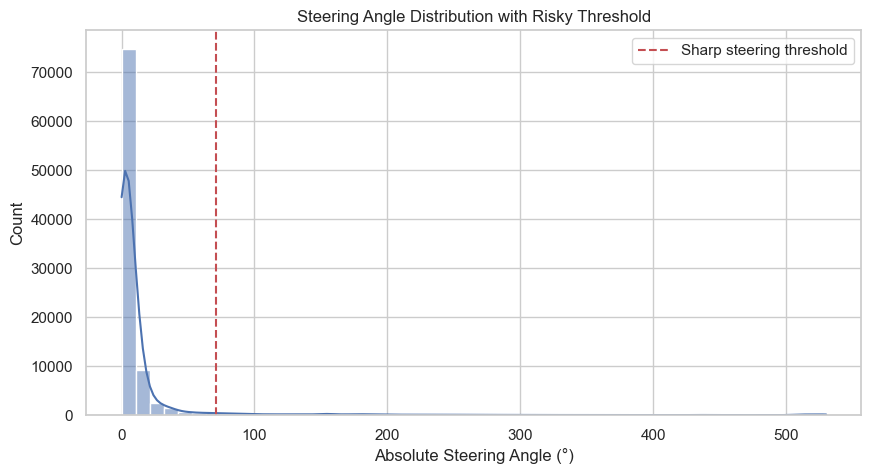

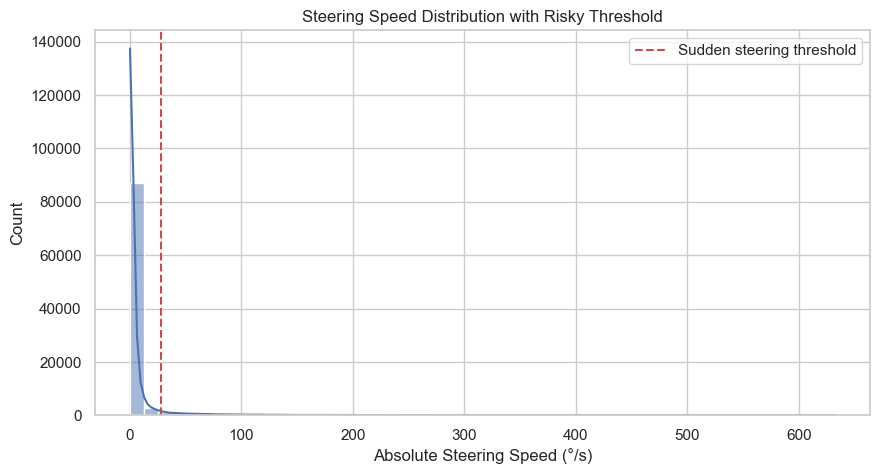

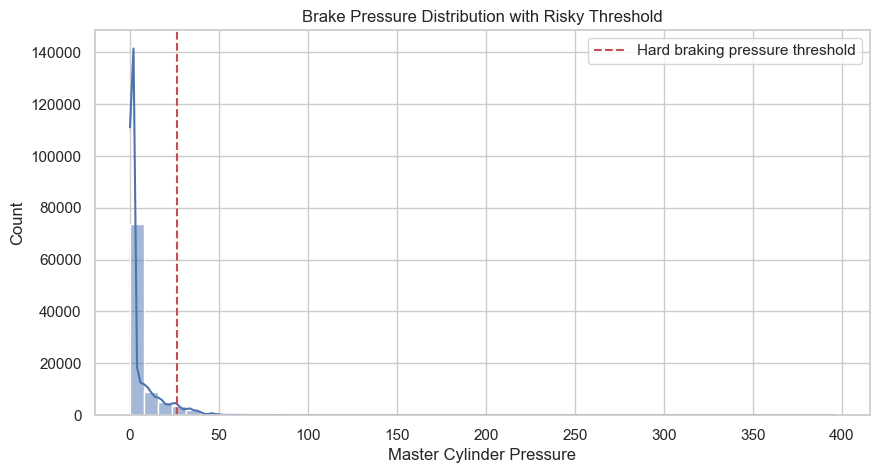

In [306]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features and their thresholds
feature_thresholds = {
    'Vehicle_speed': thresholds['Vehicle_speed'],
    'Acceleration_speed_-_Longitudinal_low': thresholds['Harsh_braking'],
    'Acceleration_speed_-_Longitudinal_high': thresholds['Hard_acceleration'],
    'Acceleration_speed_-_Lateral': thresholds['Aggressive_turn'],
    'Steering_wheel_angle': thresholds['Sharp_steering'],
    'Steering_wheel_speed': thresholds['Sudden_steering'],
    'Master_cylinder_pressure': thresholds['Hard_braking_pressure']
}

# Vehicle_speed
plt.figure(figsize=(10,5))
sns.histplot(df_features['Vehicle_speed'], bins=50, kde=True)
plt.axvline(feature_thresholds['Vehicle_speed'], color='r', linestyle='--', label='Risky speed threshold')
plt.title("Vehicle Speed Distribution with Risky Threshold")
plt.xlabel("Vehicle Speed")
plt.legend()
plt.show()

# Longitudinal acceleration
plt.figure(figsize=(10,5))
sns.histplot(df_features['Acceleration_speed_-_Longitudinal'], bins=50, kde=True)
plt.axvline(feature_thresholds['Acceleration_speed_-_Longitudinal_low'], color='r', linestyle='--', label='Harsh braking threshold')
plt.axvline(feature_thresholds['Acceleration_speed_-_Longitudinal_high'], color='g', linestyle='--', label='Hard acceleration threshold')
plt.title("Longitudinal Acceleration Distribution with Risky Thresholds")
plt.xlabel("Acceleration (m/s²)")
plt.legend()
plt.show()

# Lateral acceleration
plt.figure(figsize=(10,5))
sns.histplot(df_features['Acceleration_speed_-_Lateral'], bins=50, kde=True)
plt.axvline(feature_thresholds['Acceleration_speed_-_Lateral'], color='r', linestyle='--', label='Aggressive turn threshold')
plt.title("Lateral Acceleration Distribution with Risky Threshold")
plt.xlabel("Lateral Acceleration (m/s²)")
plt.legend()
plt.show()

# Steering angle
plt.figure(figsize=(10,5))
sns.histplot(df_features['Steering_wheel_angle'].abs(), bins=50, kde=True)
plt.axvline(feature_thresholds['Steering_wheel_angle'], color='r', linestyle='--', label='Sharp steering threshold')
plt.title("Steering Angle Distribution with Risky Threshold")
plt.xlabel("Absolute Steering Angle (°)")
plt.legend()
plt.show()

# Steering speed
plt.figure(figsize=(10,5))
sns.histplot(df_features['Steering_wheel_speed'].abs(), bins=50, kde=True)
plt.axvline(feature_thresholds['Steering_wheel_speed'], color='r', linestyle='--', label='Sudden steering threshold')
plt.title("Steering Speed Distribution with Risky Threshold")
plt.xlabel("Absolute Steering Speed (°/s)")
plt.legend()
plt.show()

# Master cylinder pressure
plt.figure(figsize=(10,5))
sns.histplot(df_features['Master_cylinder_pressure'], bins=50, kde=True)
plt.axvline(feature_thresholds['Master_cylinder_pressure'], color='r', linestyle='--', label='Hard braking pressure threshold')
plt.title("Brake Pressure Distribution with Risky Threshold")
plt.xlabel("Master Cylinder Pressure")
plt.legend()
plt.show()


In [307]:
# Create a new column 'risky' (1 = risky, 0 = normal)
df_features['risky'] = (
    (df_features['Vehicle_speed'] > thresholds['Vehicle_speed']) |
    (df_features['Acceleration_speed_-_Longitudinal'] < thresholds['Harsh_braking']) |
    (df_features['Acceleration_speed_-_Longitudinal'] > thresholds['Hard_acceleration']) |
    (df_features['Acceleration_speed_-_Lateral'] > thresholds['Aggressive_turn']) |
    (df_features['Steering_wheel_angle'].abs() > thresholds['Sharp_steering']) |
    (df_features['Steering_wheel_speed'].abs() > thresholds['Sudden_steering']) |
    (df_features['Master_cylinder_pressure'] > thresholds['Hard_braking_pressure'])
).astype(int)

# Check labeled data
df_features['risky'].value_counts()
#final decesion because there r risky events


risky
0    69618
1    24762
Name: count, dtype: int64

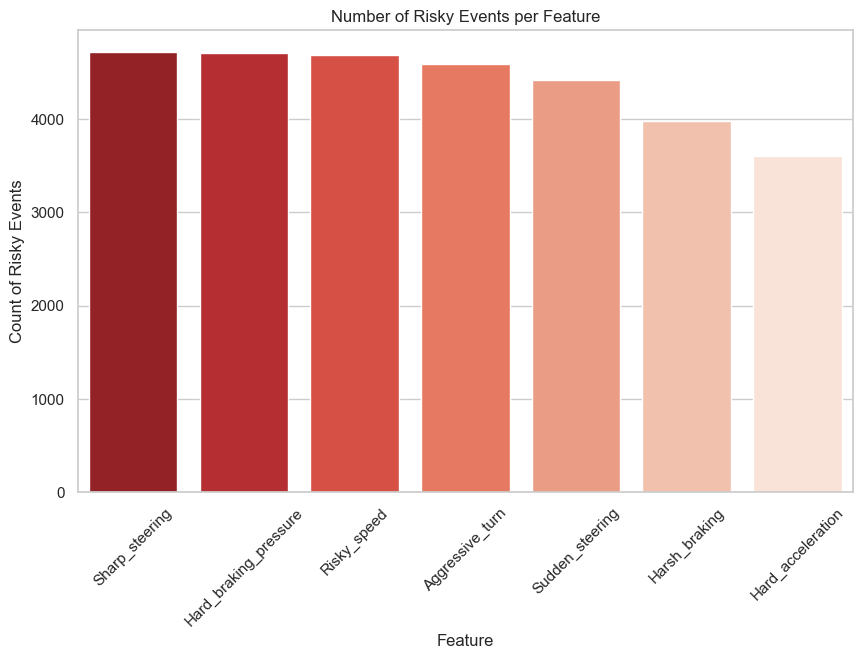

In [308]:
# Create binary columns for risky events per feature
df_features['Risky_speed'] = (df_features['Vehicle_speed'] > thresholds['Vehicle_speed']).astype(int)
df_features['Harsh_braking'] = (df_features['Acceleration_speed_-_Longitudinal'] < thresholds['Harsh_braking']).astype(int)
df_features['Hard_acceleration'] = (df_features['Acceleration_speed_-_Longitudinal'] > thresholds['Hard_acceleration']).astype(int)
df_features['Aggressive_turn'] = (df_features['Acceleration_speed_-_Lateral'] > thresholds['Aggressive_turn']).astype(int)
df_features['Sharp_steering'] = (df_features['Steering_wheel_angle'].abs() > thresholds['Sharp_steering']).astype(int)
df_features['Sudden_steering'] = (df_features['Steering_wheel_speed'].abs() > thresholds['Sudden_steering']).astype(int)
df_features['Hard_braking_pressure'] = (df_features['Master_cylinder_pressure'] > thresholds['Hard_braking_pressure']).astype(int)

# Sum risky events per feature
risky_summary = df_features[['Risky_speed','Harsh_braking','Hard_acceleration','Aggressive_turn',
                             'Sharp_steering','Sudden_steering','Hard_braking_pressure']].sum().sort_values(ascending=False)
# Convert Series to DataFrame
risky_df = risky_summary.reset_index()
risky_df.columns = ['Feature','Count']

# Plot with hue
plt.figure(figsize=(10,6))
sns.barplot(x='Feature', y='Count', data=risky_df, hue='Feature', palette="Reds_r", dodge=False, legend=False)
plt.title("Number of Risky Events per Feature")
plt.ylabel("Count of Risky Events")
plt.xticks(rotation=45)
plt.show()


In [309]:
X = df_features[
    [
        'Vehicle_speed',
        'Acceleration_speed_-_Longitudinal',
        'Acceleration_speed_-_Lateral',
        'Steering_wheel_angle',
        'Steering_wheel_speed',
        'Master_cylinder_pressure'
    ]
]

y = df_features['risky']


In [310]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [311]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8448117539026629
[[20153   732]
 [ 3662  3767]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90     20885
           1       0.84      0.51      0.63      7429

    accuracy                           0.84     28314
   macro avg       0.84      0.74      0.77     28314
weighted avg       0.84      0.84      0.83     28314



In [312]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



Random Forest Accuracy: 0.9999646817828636
[[20885     0]
 [    1  7428]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20885
           1       1.00      1.00      1.00      7429

    accuracy                           1.00     28314
   macro avg       1.00      1.00      1.00     28314
weighted avg       1.00      1.00      1.00     28314



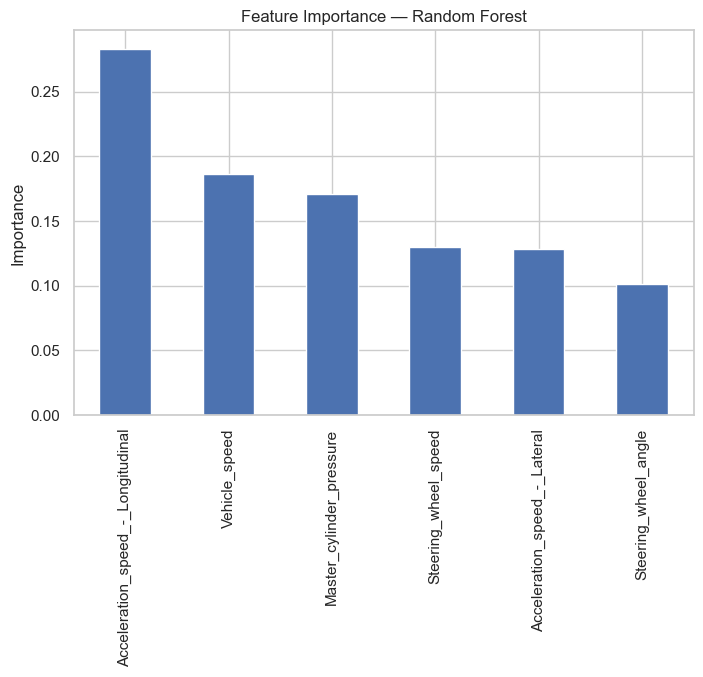

In [313]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance")
plt.show()


In [314]:
df_features["event_risk_prob"] = rf_model.predict_proba(X)[:, 1]
severity_features = [
    "Vehicle_speed",
    "Acceleration_speed_-_Longitudinal",
    "Acceleration_speed_-_Lateral",
    "Steering_wheel_angle",
    "Steering_wheel_speed",
    "Master_cylinder_pressure"
]

#Normalize severity features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_features[severity_features] = scaler.fit_transform(
    df_features[severity_features]
)




In [315]:
X = df_features[selected_features].copy()

print(X.shape)
print(X.columns)

rf_model.fit(X, y)
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

importance_df["weight"] = (
    importance_df["importance"] /
    importance_df["importance"].sum()
)

importance_df




(94380, 7)
Index(['Vehicle_speed', 'Acceleration_speed_-_Longitudinal',
       'Acceleration_speed_-_Lateral', 'Steering_wheel_angle',
       'Steering_wheel_speed', 'Master_cylinder_pressure',
       'Indication_of_brake_switch_ON/OFF'],
      dtype='object')


,feature,importance,weight
0,Vehicle_speed,0.183154,0.183154
1,Acceleration_speed_-_Longitudinal,0.278320,0.278320
2,Acceleration_speed_-_Lateral,0.126606,0.126606
3,Steering_wheel_angle,0.103403,0.103403
4,Steering_wheel_speed,0.130976,0.130976
5,Master_cylinder_pressure,0.166763,0.166763
6,Indication_of_brake_switch_ON/OFF,0.010778,0.010778


In [316]:
import numpy as np
df_features["event_weight"] = 1.0

for feature in severity_features:
    df_features["event_weight"] += (
        importance_df
        .set_index("feature")
        .loc[feature, "weight"]
        * np.abs(df_features[feature])
    )


In [317]:
#Re-attach driver column
df_features["Class"] = df.loc[df_features.index, "Class"]
df_features["Class"].value_counts()




Class
D    13244
B    12864
F    11012
H     9880
J     8904
E     8436
I     7808
C     7500
G     7492
A     7240
Name: count, dtype: int64

In [318]:
driver_scores = (
    df_features
    .groupby("Class")
    .apply(lambda x: np.average(
        x["event_risk_prob"],
        weights=x["event_weight"]
    ))
    .reset_index(name="driver_weighted_risk")
)

driver_scores["driver_score"] = (
    (1 - driver_scores["driver_weighted_risk"]) * 100
).round(1)

driver_scores


C:\Users\idris\AppData\Local\Temp\ipykernel_23556\2727452807.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(


,Class,driver_weighted_risk,driver_score
0,A,0.343075,65.7
1,B,0.244770,75.5
2,C,0.392503,60.7
3,D,0.264842,73.5
4,E,0.276910,72.3
5,F,0.231123,76.9
6,G,0.241045,75.9
7,H,0.229060,77.1
8,I,0.334119,66.6
9,J,0.277421,72.3
